# Stage 3: Held-out Test Evaluation (DRO α-mixture)

Финальная оценка 8 конфигураций (4 алгоритма × {corr, hybrid}) после Stage 2 HPO.

## Протокол

- **3 символа** (BTC/ETH/SOL) — same train universe as HPO. Out-of-sample symbols (DOGE/XRP) НЕ включены.
- **Bandit policy**: `bandit_update_policy='decision_only'`, `bandit_update_action_source='executed'`, `threshold_mode='none'`, `confidence_threshold=0.0` — синхронизировано с HPO.
- **Fitting**: каждая конфигурация запускается на `train+val` (как warm-up), evaluation на `test` (последние 2000 баров на символ).
- **Seeds**: TS — 30 fresh test seeds (9000-9029), UCB — 1 seed (9000). Все НЕ пересекаются с HPO/confirmation seeds.

## Метрики (синхронизированы с HPO)

Главная метрика — **DRO α-mixture** с α=0.5 (та же что в HPO):
$$
\text{seed\_dro\_score} = 0.5 \cdot \min(h_1, h_2) + 0.5 \cdot 0.5 \cdot (h_1 + h_2)
$$
где $h_k$ = mean_symbol(test_h$_k$ return_pct). Test разбивается на 2 равные половины. Pure-min(h1,h2) сохраняется как диагностика.

## Baselines

- screening-default бандиты (mem=325, λ=1.0, noise=0.03, ucb_α=0.10) на тех же 8 feature pairs;
- buy-and-hold (position_size=10% и full capital);
- random policy (action ∈ {0,1});
- EMA(21)/EMA(50) crossover;
- RSI(14) mean-reversion с уровнями 30/70.

## Дополнительный анализ

- Bootstrap 95% CI для hybrid − corr дельты (1000 итераций);
- Holding-time distribution per config (с MIN_HOLD=4 / HORIZON=10 contrast);
- Decision-only diagnostics (forced_singleton, decision_point ratios);
- Validation vs Test scatter (overfitting indicator).

In [1]:
import json
import sys
import gc
from pathlib import Path
from datetime import datetime
from typing import Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project root resolution
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'backtest').exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

for p in [PROJECT_ROOT, PROJECT_ROOT / 'data_processing', PROJECT_ROOT / 'backtest', PROJECT_ROOT / 'mab']:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from backtest.backtest_class import Backtesting
from data_processing.functions.stream_indicators import stream_TA_lib
from data_processing.functions.transform_indicators import transform_indicators_df
from data_processing.functions.rolling_z_score_clip import rolling_z_score_clip_df
from data_processing.functions.klines_dataloader import KlinesDataLoader

print('PROJECT_ROOT:', PROJECT_ROOT)

PROJECT_ROOT: D:\PythonProjects\BTCTrading


## 1. Protocol configuration

Все параметры синхронизированы с HPO (stage2_hpo_dro_minimax.py).

In [2]:
# =====================================================================
# Paths
# =====================================================================
FEATURE_SELECTION_ROOT = PROJECT_ROOT / 'feature_selection' / 'bs_stable_hie_outputs_alpha0p5_train_only'
FEATURE_SETS_PATH = FEATURE_SELECTION_ROOT / 'feature_sets_hybrid_corr_bs_stable_hie_alpha0p5.json'
HYPERPARAM_OPT_ROOT = PROJECT_ROOT / 'hyperparameters_optimization'
EVALUATION_ROOT = PROJECT_ROOT / 'evaluation'

# HPO runs (DRO α=0.5 version, full HPO May 22)
RUN_LABELS = {
    'A_discounted': 'A_discounted_20260524_184336',
    'B_sliding':    'B_sliding_20260525_030438',
}
OPTUNA_OUTPUT_ROOT = HYPERPARAM_OPT_ROOT / 'stage2_dro_minimax_outputs'

def resolve_run_dir(label: str) -> Path:
    direct = OPTUNA_OUTPUT_ROOT / label
    if not direct.exists():
        raise FileNotFoundError(f'HPO run dir not found: {direct}')
    return direct

RUN_DIRS = {k: resolve_run_dir(v) for k, v in RUN_LABELS.items()}

def assert_hpo_run_consistency(run_dir: Path):
    """Verify HPO run protocol matches Stage 3 (DRO_ALPHA, decision_only, symbols, etc).
    Protects against accidentally evaluating on an old HPO run."""
    cfg_path = run_dir / 'optuna_stage2_config.json'
    if not cfg_path.exists():
        raise FileNotFoundError(f'Missing HPO config: {cfg_path}')
    cfg = json.loads(cfg_path.read_text(encoding='utf-8'))
    obj = cfg.get('objective', {})
    ex  = cfg.get('execution', {})
    checks = [
        ('objective.dro_alpha',                    float(obj.get('dro_alpha', -1.0)),    float(DRO_ALPHA)),
        ('execution.threshold_mode',               ex.get('threshold_mode'),              THRESHOLD_MODE),
        ('execution.bandit_update_action_source',  ex.get('bandit_update_action_source'), BANDIT_UPDATE_ACTION_SOURCE),
        ('execution.bandit_update_policy',         ex.get('bandit_update_policy'),        BANDIT_UPDATE_POLICY),
        ('execution.horizon',                      int(ex.get('horizon', -1)),            int(HORIZON)),
        ('execution.min_hold_bars',                int(ex.get('min_hold_bars', -1)),      int(MIN_HOLD_BARS)),
        ('execution.cooldown_bars',                int(ex.get('cooldown_bars', -1)),      int(COOLDOWN_BARS)),
        ('symbols',                                 cfg.get('symbols'),                    ALL_SYMBOLS),
        ('state_features',                          cfg.get('state_features'),             STATE_FEATURES),
    ]
    mismatches = [(n, h, e) for n, h, e in checks if h != e]
    if mismatches:
        msg = '\n'.join(f'  {n}: HPO={h!r}  expected={e!r}' for n, h, e in mismatches)
        raise AssertionError(f'HPO run {run_dir.name} mismatch with Stage 3:\n{msg}')
    print(f'  consistency OK: {run_dir.name}')




# Output paths
FINAL_TEST_RUN_LABEL = f"stage3_test_eval_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
OUTPUT_DIR = EVALUATION_ROOT / 'final_test_evaluation_outputs' / FINAL_TEST_RUN_LABEL
DIAGNOSTICS_DIR = OUTPUT_DIR / 'diagnostics'
PLOTS_DIR = OUTPUT_DIR / 'plots'
for d in [OUTPUT_DIR, DIAGNOSTICS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# =====================================================================
# Trading protocol — synced with HPO
# =====================================================================
ALL_SYMBOLS = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT']  # 3-symbol in-sample universe
META_COLS = ['timestamp', 'symbol', 'open', 'high', 'low', 'close', 'volume']
STATE_FEATURES = ['state_in_position']
ACTIONS = [0, 1]  # binary action space — required by bandit constructors

VAL_BARS = 2000
TEST_BARS = 2000
EMBARGO_BARS = 0
HORIZON = 10
TRADE_COST = 0.0025
ALPHA_OUT = 0.5

START_CAPITAL = 100.0
POSITION_SIZE = 0.10
MIN_HOLD_BARS = 4
COOLDOWN_BARS = 2
REWARD_CLIP = 0.10

# Decision policy — synced with HPO
THRESHOLD_MODE = 'none'
CONFIDENCE_THRESHOLD = 0.0
BANDIT_UPDATE_ACTION_SOURCE = 'raw'
BANDIT_UPDATE_POLICY = 'all_bars'
UPDATE_ON_TEST = True   # bandit keeps learning online on test phase

# DRO objective — synced with HPO
DRO_ALPHA = 0.5
PF_INF_CAP = 10.0  # cap +inf PF before median aggregation

# =====================================================================
# Test seeds (NON-overlapping with HPO 3142-3146 + confirmation 8000-8024)
# =====================================================================
TEST_TS_SEEDS = list(range(9000, 9030))   # 30 TS seeds
TEST_UCB_SEEDS = [9000]                    # 1 UCB seed
RANDOM_POLICY_SEEDS = list(range(9100, 9130))

SMOKE_TEST = False
if SMOKE_TEST:
    TEST_TS_SEEDS = TEST_TS_SEEDS[:2]
    RANDOM_POLICY_SEEDS = RANDOM_POLICY_SEEDS[:2]

# =====================================================================
# Screening default params (for default baselines)
# =====================================================================
DEFAULT_MEMORY_HORIZON_BARS = 325
DEFAULT_DISCOUNT_FACTOR = 1.0 - 1.0 / DEFAULT_MEMORY_HORIZON_BARS
DEFAULT_WINDOW_SIZE = DEFAULT_MEMORY_HORIZON_BARS
DEFAULT_LAMBDA_PRIOR = 1.0
DEFAULT_NOISE_STD = 0.03
DEFAULT_UCB_ALPHA = 0.10

TS_BANDITS = {'discounted_lints', 'sw_lints'}
UCB_BANDITS = {'discounted_linucb', 'sw_linucb'}
BANDIT_TYPE_MAP = {a: a for a in (TS_BANDITS | UCB_BANDITS)}

# =====================================================================
# Baseline toggles
# =====================================================================
RUN_OPTIMIZED_CONFIGS = True
RUN_DEFAULT_BANDIT_BASELINES = True
RUN_STATIC_BASELINES = True
RUN_RANDOM_BASELINE = True
RUN_RULE_BASELINES = True
APPLY_EXECUTION_CONSTRAINTS_TO_RULE_BASELINES = True
BASELINE_Z_WINDOW = 24

# Bootstrap CI for hybrid - corr deltas
BOOTSTRAP_N_ITER = 1000
BOOTSTRAP_SEED = 42

# =====================================================================
# OHLCV path
# =====================================================================
OHLCV_RELATIVE_PATH = 'data/klines_data/crypto_240m_bybit_TEST.parquet'

print('OUTPUT_DIR:', OUTPUT_DIR)
print('DRO_ALPHA:', DRO_ALPHA)
print('Symbols:', ALL_SYMBOLS)
for k, p in RUN_DIRS.items():
    print(k, 'exists=', p.exists(), 'path=', p)
print('\nAsserting HPO run consistency with Stage 3 protocol...')
for _name, _p in RUN_DIRS.items():
    assert_hpo_run_consistency(_p)


OUTPUT_DIR: D:\PythonProjects\BTCTrading\evaluation\final_test_evaluation_outputs\stage3_test_eval_20260525_044134
DRO_ALPHA: 0.5
Symbols: ['BTCUSDT', 'ETHUSDT', 'SOLUSDT']
A_discounted exists= True path= D:\PythonProjects\BTCTrading\hyperparameters_optimization\stage2_dro_minimax_outputs\A_discounted_20260524_184336
B_sliding exists= True path= D:\PythonProjects\BTCTrading\hyperparameters_optimization\stage2_dro_minimax_outputs\B_sliding_20260525_030438

Asserting HPO run consistency with Stage 3 protocol...
  consistency OK: A_discounted_20260524_184336
  consistency OK: B_sliding_20260525_030438


## 2. Load 8 final configurations from HPO

Reading from new HPO outputs:
- `final_selection_per_algorithm_method.csv` — final selection (TS via confirmation, UCB via HPO best)
- `study_best_summary.csv` — full parameters of best trial
- `feature_pairs_to_optimize.csv` — feature lists per pair

In [3]:
def read_required_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'Missing required file: {path}')
    return pd.read_csv(path)


def parse_features(s: Any) -> list[str]:
    if isinstance(s, list):
        return list(s)
    if pd.isna(s):
        return []
    return [x for x in str(s).split('|') if x]


def default_bandit_params(algorithm: str) -> dict:
    params = {
        'bandit_type': BANDIT_TYPE_MAP[algorithm],
        'lambda_prior': DEFAULT_LAMBDA_PRIOR,
        'reward_clip': REWARD_CLIP,
    }
    if algorithm.startswith('discounted'):
        params['discount_factor'] = DEFAULT_DISCOUNT_FACTOR
    else:
        params['window_size'] = DEFAULT_WINDOW_SIZE
    if algorithm in TS_BANDITS:
        params['noise_std'] = DEFAULT_NOISE_STD
    else:
        params['ucb_alpha'] = DEFAULT_UCB_ALPHA
    return params


def params_from_best_summary_row(row: pd.Series) -> dict:
    algorithm = str(row['bandit_name'])
    params = {
        'bandit_type': BANDIT_TYPE_MAP[algorithm],
        'lambda_prior': float(row['best_param_lambda_prior']),
        'reward_clip': REWARD_CLIP,
    }
    if algorithm.startswith('discounted'):
        one_minus_g = float(row['best_param_one_minus_gamma'])
        params['discount_factor'] = float(1.0 - one_minus_g)
    else:
        params['window_size'] = int(row['best_param_window_size'])
    if algorithm in TS_BANDITS:
        params['noise_std'] = float(row['best_param_noise_std'])
    else:
        params['ucb_alpha'] = float(row['best_param_ucb_alpha'])
    return params


def load_final_configs_from_run(run_name: str, run_dir: Path) -> pd.DataFrame:
    final_sel = read_required_csv(run_dir / 'final_selection_per_algorithm_method.csv')
    # Sanity: all selected configs must be feasible + complete (no fallback winners).
    if 'selected_feasible' in final_sel.columns:
        infeasible = final_sel[~final_sel['selected_feasible'].astype(bool)]
        if len(infeasible):
            raise ValueError(
                f'HPO run {run_dir.name} has infeasible selected configs:\n'
                + infeasible[['bandit_name', 'method_group', 'selected_trial_number', 'selected_dro']].to_string()
            )
    if 'selected_complete' in final_sel.columns:
        incomplete = final_sel[~final_sel['selected_complete'].astype(bool)]
        if len(incomplete):
            raise ValueError(
                f'HPO run {run_dir.name} has incomplete selected configs:\n'
                + incomplete[['bandit_name', 'method_group', 'selected_trial_number']].to_string()
            )
    if 'is_fallback_infeasible' in final_sel.columns:
        fb = final_sel[final_sel['is_fallback_infeasible'].astype(bool)]
        if len(fb):
            raise ValueError(
                f'HPO run {run_dir.name} has fallback-infeasible selected configs:\n'
                + fb[['bandit_name', 'method_group', 'selected_trial_number']].to_string()
            )
    feature_pairs = read_required_csv(run_dir / 'feature_pairs_to_optimize.csv')
    study_best = read_required_csv(run_dir / 'study_best_summary.csv')

    rows = []
    for _, sel in final_sel.iterrows():
        algorithm = str(sel['bandit_name'])
        method_group = str(sel['method_group'])
        set_name = str(sel['set_name'])

        # Feature pair
        fp_mask = (
            feature_pairs['algorithm'].astype(str).eq(algorithm)
            & feature_pairs['method_group'].astype(str).eq(method_group)
            & feature_pairs['set_name'].astype(str).eq(set_name)
        )
        if not fp_mask.any():
            raise ValueError(f'No feature pair for {algorithm}/{method_group}/{set_name}')
        fp = feature_pairs[fp_mask].iloc[0]

        # Best trial params (from study_best_summary; final selection points to trial number via selected_trial_number)
        sb_mask = (
            study_best['bandit_name'].astype(str).eq(algorithm)
            & study_best['method_group'].astype(str).eq(method_group)
            & study_best['set_name'].astype(str).eq(set_name)
        )
        if not sb_mask.any():
            raise ValueError(f'No study_best_summary row for {algorithm}/{method_group}/{set_name}')
        # study_best_summary contains the HPO best trial. For TS, the actual final
        # is the confirmation winner (which may differ). Reread params from
        # ts_best_trial_per_algorithm_method_after_confirmation.csv for TS bandits.
        if algorithm in TS_BANDITS:
            ts_conf_path = run_dir / 'ts_best_trial_per_algorithm_method_after_confirmation.csv'
            ts_conf = read_required_csv(ts_conf_path)
            tcmask = (
                ts_conf['bandit_name'].astype(str).eq(algorithm)
                & ts_conf['method_group'].astype(str).eq(method_group)
                & ts_conf['set_name'].astype(str).eq(set_name)
            )
            if not tcmask.any():
                raise ValueError(f'No TS confirmation row for {algorithm}/{method_group}/{set_name}')
            tc = ts_conf[tcmask].iloc[0]
            # ts_confirmation already contains param_* fields
            params = {
                'bandit_type': BANDIT_TYPE_MAP[algorithm],
                'lambda_prior': float(tc['param_lambda_prior']),
                'reward_clip': float(tc.get('param_reward_clip', REWARD_CLIP)),
            }
            if algorithm.startswith('discounted'):
                # Robust: TS confirmation table may store either param_discount_factor
                # OR param_one_minus_gamma (depending on HPO export version).
                if 'param_discount_factor' in tc.index and pd.notna(tc.get('param_discount_factor', float('nan'))):
                    params['discount_factor'] = float(tc['param_discount_factor'])
                elif 'param_one_minus_gamma' in tc.index and pd.notna(tc.get('param_one_minus_gamma', float('nan'))):
                    params['discount_factor'] = float(1.0 - float(tc['param_one_minus_gamma']))
                else:
                    raise KeyError(
                        f'Missing discount parameter in TS confirmation row for '
                        f'{algorithm}/{method_group}/{set_name}: need param_discount_factor or param_one_minus_gamma'
                    )
            else:
                params['window_size'] = int(tc['param_window_size'])
            params['noise_std'] = float(tc['param_noise_std'])
            selection_source = 'ts_confirmation'
            selected_trial_number = int(tc['original_trial_number'])
            validation_selected_dro = float(sel['selected_dro'])
        else:
            params = params_from_best_summary_row(study_best[sb_mask].iloc[0])
            selection_source = 'hpo_best'
            selected_trial_number = int(study_best[sb_mask].iloc[0]['best_trial_number'])
            validation_selected_dro = float(sel['selected_dro'])

        features = parse_features(fp['features'])
        rows.append({
            'run_name': run_name,
            'config_type': 'optimized',
            'algorithm': algorithm,
            'bandit_name': algorithm,
            'algorithm_family': 'discounted' if algorithm.startswith('discounted') else 'sliding_window',
            'exploration_family': 'TS' if algorithm in TS_BANDITS else 'UCB',
            'method_group': method_group,
            'set_name': set_name,
            'z_window': int(fp['z_window']),
            'features': features,
            'n_market_features': len(features),
            'n_state_features': len(STATE_FEATURES),
            'n_total_features': len(features) + len(STATE_FEATURES),
            'bandit_params': params,
            'bandit_params_json': json.dumps(params, ensure_ascii=False, sort_keys=True),
            'selected_trial_number': selected_trial_number,
            'selection_source': selection_source,
            'validation_selected_dro': validation_selected_dro,
            'validation_selected_drawdown_abs': float(sel.get('selected_dd', np.nan)),
            'validation_selected_profit_factor': float(sel.get('selected_pf', np.nan)),
            'validation_selected_total_trades': float(sel.get('selected_trades', np.nan)),
        })
    return pd.DataFrame(rows)


optimized_configs_list = []
for run_name, run_dir in RUN_DIRS.items():
    optimized_configs_list.append(load_final_configs_from_run(run_name, run_dir))
OPTIMIZED_CONFIGS = pd.concat(optimized_configs_list, ignore_index=True)

# Defaults: same feature pairs + screening default bandit params
DEFAULT_CONFIGS = OPTIMIZED_CONFIGS.copy()
DEFAULT_CONFIGS['config_type'] = 'screening_default'
DEFAULT_CONFIGS['selection_source'] = 'screening_default_params'
DEFAULT_CONFIGS['selected_trial_number'] = 0
DEFAULT_CONFIGS['validation_selected_dro'] = np.nan
DEFAULT_CONFIGS['validation_selected_drawdown_abs'] = np.nan
DEFAULT_CONFIGS['validation_selected_profit_factor'] = np.nan
DEFAULT_CONFIGS['validation_selected_total_trades'] = np.nan
DEFAULT_CONFIGS['bandit_params'] = DEFAULT_CONFIGS['algorithm'].map(default_bandit_params)
DEFAULT_CONFIGS['bandit_params_json'] = DEFAULT_CONFIGS['bandit_params'].map(lambda d: json.dumps(d, ensure_ascii=False, sort_keys=True))

CONFIGS_TO_TEST = OPTIMIZED_CONFIGS.copy()
if RUN_DEFAULT_BANDIT_BASELINES:
    CONFIGS_TO_TEST = pd.concat([CONFIGS_TO_TEST, DEFAULT_CONFIGS], ignore_index=True)

CONFIGS_TO_TEST['config_id'] = (
    CONFIGS_TO_TEST['config_type'] + '__'
    + CONFIGS_TO_TEST['algorithm'] + '__'
    + CONFIGS_TO_TEST['method_group']
)
CONFIGS_TO_TEST['features_pipe'] = CONFIGS_TO_TEST['features'].map(lambda xs: '|'.join(xs))

export_cols = [
    'config_id', 'config_type', 'algorithm', 'algorithm_family', 'exploration_family',
    'method_group', 'set_name', 'z_window', 'n_market_features', 'n_state_features',
    'features_pipe', 'selected_trial_number', 'selection_source',
    'validation_selected_dro', 'bandit_params_json',
]
CONFIGS_TO_TEST[export_cols].to_csv(OUTPUT_DIR / 'final_test_configurations.csv', index=False)

print('Optimized configs (from HPO):')
print(OPTIMIZED_CONFIGS[['algorithm', 'method_group', 'z_window', 'selected_trial_number',
                         'validation_selected_dro', 'bandit_params_json']].to_string(index=False))
print(f'\nTotal configs to evaluate (incl defaults): {len(CONFIGS_TO_TEST)}')

Optimized configs (from HPO):
        algorithm method_group  z_window  selected_trial_number  validation_selected_dro                                                                                                                                                   bandit_params_json
 discounted_lints         corr        48                     40                -2.547262    {"bandit_type": "discounted_lints", "discount_factor": 0.9977634039937956, "lambda_prior": 0.60425844975987, "noise_std": 0.0031120036514668, "reward_clip": 0.1}
 discounted_lints       hybrid        72                     44                -1.105173  {"bandit_type": "discounted_lints", "discount_factor": 0.9977749371167904, "lambda_prior": 0.6589189740952492, "noise_std": 0.0022048611431712, "reward_clip": 0.1}
discounted_linucb         corr        48                     22                -2.030339 {"bandit_type": "discounted_linucb", "discount_factor": 0.9974921820137075, "lambda_prior": 0.8138243181666224, "reward

## 3. Dataset loading

Загружаем OHLCV и строим z-window-нормированные feature наборы для каждого нужного z (24/48/72).
Cache в `stage2_optuna_feature_cache/` переиспользуется если есть.

In [4]:
FEATURE_CACHE_DIR = HYPERPARAM_OPT_ROOT / 'stage2_optuna_feature_cache'
FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

INDICATOR_CONFIG = {
    'ema_periods': [9, 21, 50, 100, 200],
    'momentum_indicators_periods': [14, 30, 72],
    'return_indicators_periods': [6, 24, 72, 168],
    'volatility_indicators_periods': [24, 72, 168],
    'level_periods': [24, 72, 168],
    'vol_ma_period': [24, 72, 168],
    'range_ma_period': [24, 72, 168],
}


def process_indicators_for_z_window(ohlcv: pd.DataFrame, z_window: int) -> pd.DataFrame:
    """Same pipeline as HPO/screening: stream indicators → transform → rolling z-score → concat → dropna.
    Aligned with screening_bs_stable_vs_corr.py and stage2_hpo_dro_minimax.py.
    """
    parts = []
    for symbol in ALL_SYMBOLS:
        df_sym = ohlcv[ohlcv['symbol'] == symbol].sort_values('timestamp').reset_index(drop=True)
        ind = stream_TA_lib(df=df_sym, meta_cols=META_COLS, **INDICATOR_CONFIG)
        tr = transform_indicators_df(df=ind, meta_cols=META_COLS)
        z = rolling_z_score_clip_df(df=tr, meta_cols=META_COLS, window=z_window, clip_value=5.0, shift_by_one=True)
        parts.append(z)
    out = pd.concat(parts, ignore_index=True)
    feat_cols = [c for c in out.columns if c not in META_COLS]
    # dropna over feature cols + META_COLS — strict alignment with screening/HPO preprocessing
    out = out.replace([np.inf, -np.inf], np.nan).dropna(subset=feat_cols + META_COLS)
    return out.sort_values(['symbol', 'timestamp']).reset_index(drop=True)


def split_by_symbol_tail(df: pd.DataFrame) -> tuple[dict[str, pd.DataFrame], pd.DataFrame]:
    out = {'train': [], 'val': [], 'test': []}
    rows = []
    for sym in ALL_SYMBOLS:
        g = df[df['symbol'].eq(sym)].sort_values('timestamp').reset_index(drop=True)
        n = len(g)
        train_end = n - VAL_BARS - TEST_BARS - EMBARGO_BARS
        val_start = n - VAL_BARS - TEST_BARS
        test_start = n - TEST_BARS
        if train_end <= 0:
            raise ValueError(f'Not enough rows for {sym}: {n}')
        out['train'].append(g.iloc[:train_end].copy())
        out['val'].append(g.iloc[val_start:test_start].copy())
        out['test'].append(g.iloc[test_start:].copy())
        rows.append({
            'symbol': sym, 'n_total': n,
            'train_rows': train_end, 'val_rows': VAL_BARS, 'test_rows': TEST_BARS,
            'train_start': g.iloc[0]['timestamp'], 'train_end': g.iloc[train_end - 1]['timestamp'],
            'val_start': g.iloc[val_start]['timestamp'], 'val_end': g.iloc[test_start - 1]['timestamp'],
            'test_start': g.iloc[test_start]['timestamp'], 'test_end': g.iloc[-1]['timestamp'],
        })
    datasets = {k: pd.concat(v, ignore_index=True).sort_values(['symbol', 'timestamp']).reset_index(drop=True)
                for k, v in out.items()}
    return datasets, pd.DataFrame(rows)


needed_z_windows = sorted(set(CONFIGS_TO_TEST['z_window'].astype(int).tolist() + [BASELINE_Z_WINDOW]))
print('needed_z_windows:', needed_z_windows)

DATASETS_BY_Z: dict[int, dict[str, pd.DataFrame]] = {}
split_summaries = []
ohlcv_data = None

for z in needed_z_windows:
    # Cache key includes version tag + symbol set so stale caches from older
    # preprocessing (different decision_only / DRO_ALPHA semantics, different symbols)
    # are not silently loaded.
    _syms = '_'.join(ALL_SYMBOLS)
    cache_name = f'datasets_v4_z{z}_symbols{_syms}_val{VAL_BARS}_test{TEST_BARS}_embargo{EMBARGO_BARS}.pkl'
    cache_path = FEATURE_CACHE_DIR / cache_name
    if cache_path.exists():
        print(f'Loading cached z={z}: {cache_path.name}')
        cached = pd.read_pickle(cache_path)
        DATASETS_BY_Z[z] = cached['datasets']
        split_summaries.append(cached['split_summary'])
    else:
        if ohlcv_data is None:
            loader = KlinesDataLoader(symbols=ALL_SYMBOLS)
            ohlcv_data = loader.load_data(download_path=OHLCV_RELATIVE_PATH, analyse_data=False, cleaning=True)
            ohlcv_data['timestamp'] = pd.to_datetime(ohlcv_data['timestamp'], utc=True)
            ohlcv_data = ohlcv_data[ohlcv_data['symbol'].isin(ALL_SYMBOLS)].sort_values(['symbol', 'timestamp']).reset_index(drop=True)
        print(f'Building features for z={z}...')
        zdf = process_indicators_for_z_window(ohlcv_data, z)
        datasets, split_summary = split_by_symbol_tail(zdf)
        DATASETS_BY_Z[z] = datasets
        split_summaries.append(split_summary)
        # Save cache
        pd.to_pickle({'datasets': datasets, 'split_summary': split_summary}, cache_path)

SPLIT_SUMMARY_USED = pd.concat(split_summaries, ignore_index=True) if split_summaries else pd.DataFrame()
SPLIT_SUMMARY_USED.to_csv(DIAGNOSTICS_DIR / 'test_split_summary_used.csv', index=False)
print(SPLIT_SUMMARY_USED[['symbol', 'n_total', 'train_rows', 'val_rows', 'test_rows', 'test_start', 'test_end']].drop_duplicates().to_string(index=False))

needed_z_windows: [24, 48, 72]
Building features for z=24...
Building features for z=48...
Building features for z=72...
 symbol  n_total  train_rows  val_rows  test_rows                test_start                  test_end
BTCUSDT     9674        5674      2000       2000 2025-05-30 08:00:00+00:00 2026-04-28 12:00:00+00:00
ETHUSDT     9674        5674      2000       2000 2025-05-30 08:00:00+00:00 2026-04-28 12:00:00+00:00
SOLUSDT     9674        5674      2000       2000 2025-05-30 08:00:00+00:00 2026-04-28 12:00:00+00:00
BTCUSDT     9650        5650      2000       2000 2025-05-30 08:00:00+00:00 2026-04-28 12:00:00+00:00
ETHUSDT     9650        5650      2000       2000 2025-05-30 08:00:00+00:00 2026-04-28 12:00:00+00:00
SOLUSDT     9650        5650      2000       2000 2025-05-30 08:00:00+00:00 2026-04-28 12:00:00+00:00
BTCUSDT     9626        5626      2000       2000 2025-05-30 08:00:00+00:00 2026-04-28 12:00:00+00:00
ETHUSDT     9626        5626      2000       2000 2025-05-30 08

## 4. Metric helpers

Метрики на трёх уровнях:
1. `symbol_metrics`: per-symbol per-seed (с разделением test → test_first / test_second halves для DRO);
2. `seed_summary`: aggregate over symbols (с computation DRO α-mixture);
3. `config_summary`: aggregate over seeds.

**Главная метрика**: `seed_dro_score = α·min(h1,h2) + (1-α)·0.5·(h1+h2)`.  
Диагностика: `seed_dro_pure_min` (α=1.0), `median_holding_bars`, `share_trades_closed_before_horizon`, `forced_singleton_ratio`, `decision_point_ratio`.

In [5]:
def get_store(bt, mode: str, store_name: str):
    if mode == 'train':
        return getattr(bt, f'{store_name}_train')
    if mode in {'val', 'test'}:
        return getattr(bt, f'{store_name}_val')
    raise ValueError("mode must be train/val/test")


def compute_balance_return_and_drawdown(balance: np.ndarray, initial_capital: float = START_CAPITAL):
    balance = np.asarray(balance, dtype=float)
    if len(balance) == 0:
        return np.nan, np.nan, np.array([])
    end_value = float(balance[-1])
    return_pct = (end_value / initial_capital - 1.0) * 100.0
    equity = np.r_[initial_capital, balance]
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / (running_max + 1e-12) - 1.0
    max_dd = abs(float(drawdown.min() * 100.0))
    return return_pct, max_dd, drawdown


def extract_trade_stats_from_log(trade_log: list[dict], trade_cost: float) -> pd.DataFrame:
    if not trade_log:
        return pd.DataFrame()
    events = pd.DataFrame(trade_log).copy()
    if events.empty or 'event' not in events.columns:
        return pd.DataFrame()
    events['timestamp'] = pd.to_datetime(events['timestamp'], utc=True)
    trades = []
    open_trade = None
    for _, row in events.sort_values('timestamp').iterrows():
        if row['event'] == 'BUY':
            open_trade = row
        elif row['event'] == 'SELL' and open_trade is not None:
            entry_price = float(open_trade['price'])
            exit_price = float(row['price'])
            pnl_before = float(np.log(exit_price / entry_price))
            pnl_after = float(pnl_before + 2.0 * np.log(1.0 - trade_cost))
            ht = pd.to_datetime(row['timestamp'], utc=True) - pd.to_datetime(open_trade['timestamp'], utc=True)
            holding_bars = ht / pd.Timedelta(hours=4)
            trades.append({
                'entry_timestamp': open_trade['timestamp'],
                'exit_timestamp': row['timestamp'],
                'entry_price': entry_price,
                'exit_price': exit_price,
                'pnl_after_cost_log': pnl_after,
                'pnl_after_cost_pct': (np.exp(pnl_after) - 1.0) * 100.0,
                'holding_bars': float(holding_bars),
            })
            open_trade = None
    return pd.DataFrame(trades)


def trade_metrics_from_trades(trades: pd.DataFrame, horizon: int = HORIZON) -> dict:
    if trades.empty:
        return {
            'closed_trades': 0, 'win_rate': np.nan, 'profit_factor': np.nan,
            'avg_trade_return_pct': np.nan, 'median_trade_return_pct': np.nan,
            'avg_holding_bars': np.nan, 'median_holding_bars': np.nan,
            'share_trades_closed_before_horizon': np.nan,
            'share_trades_closed_after_horizon': np.nan,
        }
    pnl = trades['pnl_after_cost_log'].astype(float)
    gross_profit = float(pnl[pnl > 0].sum())
    gross_loss = float(pnl[pnl < 0].sum())
    if abs(gross_loss) < 1e-12:
        pf = np.inf if gross_profit > 0 else np.nan
    else:
        pf = gross_profit / abs(gross_loss)
    hb = trades['holding_bars'].astype(float)
    return {
        'closed_trades': int(len(trades)),
        'win_rate': float((pnl > 0).mean()),
        'profit_factor': float(pf) if np.isfinite(pf) else pf,
        'avg_trade_return_pct': float((np.exp(pnl.mean()) - 1.0) * 100.0),
        'median_trade_return_pct': float(trades['pnl_after_cost_pct'].median()),
        'avg_holding_bars': float(hb.mean()),
        'median_holding_bars': float(hb.median()),
        'share_trades_closed_before_horizon': float((hb < horizon).mean()),
        'share_trades_closed_after_horizon':  float((hb >= horizon).mean()),
    }


def decision_log_diagnostics(decision_log: pd.DataFrame) -> dict:
    """Extract decision-only diagnostics from decision_log DataFrame."""
    if decision_log.empty:
        return {
            'forced_singleton_ratio': np.nan, 'decision_point_ratio': np.nan,
            'bandit_consulted_ratio': np.nan, 'pending_update_queued_ratio': np.nan,
            'constraint_applied_ratio': np.nan, 'raw_executed_mismatch_ratio': np.nan,
        }
    out = {}
    out['forced_singleton_ratio'] = float((decision_log.get('is_decision_point', pd.Series(dtype=bool)) == False).mean()) if 'is_decision_point' in decision_log else np.nan
    out['decision_point_ratio'] = float(decision_log.get('is_decision_point', pd.Series(dtype=bool)).astype(bool).mean()) if 'is_decision_point' in decision_log else np.nan
    out['bandit_consulted_ratio'] = float(decision_log.get('bandit_consulted', pd.Series(dtype=bool)).astype(bool).mean()) if 'bandit_consulted' in decision_log else np.nan
    out['pending_update_queued_ratio'] = float(decision_log.get('pending_update_queued', pd.Series(dtype=bool)).astype(bool).mean()) if 'pending_update_queued' in decision_log else np.nan
    out['constraint_applied_ratio'] = float(decision_log.get('constraint_applied', pd.Series(dtype=bool)).astype(bool).mean()) if 'constraint_applied' in decision_log else np.nan
    if 'raw_action' in decision_log and 'executed_action' in decision_log:
        out['raw_executed_mismatch_ratio'] = float((decision_log['raw_action'] != decision_log['executed_action']).mean())
    else:
        out['raw_executed_mismatch_ratio'] = np.nan
    return out


def compute_symbol_backtest_metrics(bt, sym: str, phase_store: str, trade_cost: float) -> list[dict]:
    """Returns list of dicts: one for mode='test' (full), one for 'test_first', one for 'test_second'."""
    balance = np.asarray(get_store(bt, phase_store, 'balance').get(sym, []), dtype=float)
    actions = np.asarray(get_store(bt, phase_store, 'actions').get(sym, []), dtype=float)
    raw_actions = np.asarray(get_store(bt, phase_store, 'raw_actions').get(sym, []), dtype=float)
    decision_log = pd.DataFrame(get_store(bt, phase_store, 'decision_log').get(sym, []))
    trade_log = get_store(bt, phase_store, 'trade_log').get(sym, [])
    times = get_store(bt, phase_store, 'times').get(sym, [])

    if len(balance) == 0:
        return [{'symbol': sym, 'mode': 'test', 'n_decisions': 0}]

    # Full test metrics
    ret_full, dd_full, _ = compute_balance_return_and_drawdown(balance)
    trades_full = extract_trade_stats_from_log(trade_log, trade_cost)
    tmet_full = trade_metrics_from_trades(trades_full)
    dlog_full = decision_log_diagnostics(decision_log)

    rows = []
    rows.append({
        'symbol': sym, 'mode': 'test',
        'start_value': START_CAPITAL, 'end_value': float(balance[-1]),
        'return_pct': float(ret_full), 'max_drawdown_abs': float(dd_full),
        'drawdown_abs': float(dd_full),
        'calmar_like': float(ret_full / (dd_full + 1e-12)),
        'n_decisions': int(len(actions)),
        'executed_action_1_ratio': float(np.mean(actions == 1)) if len(actions) else np.nan,
        'raw_action_1_ratio': float(np.mean(raw_actions == 1)) if len(raw_actions) else np.nan,
        'executed_long_ratio': float(np.mean(actions == 1)) if len(actions) else np.nan,
        'trade_events': len(trade_log),
        'turnover': float(len(trade_log) / max(len(actions), 1)),
        **tmet_full,
        **dlog_full,
    })

    # Split test into two halves for DRO computation
    n = len(balance)
    mid = n // 2
    for half_name, idx_start, idx_end in [('test_first', 0, mid), ('test_second', mid, n)]:
        if idx_end - idx_start < 5:
            rows.append({'symbol': sym, 'mode': half_name, 'n_decisions': 0})
            continue
        # Re-base half to START_CAPITAL for fair half-comparison
        seg_balance = balance[idx_start:idx_end]
        base = balance[idx_start - 1] if idx_start > 0 else START_CAPITAL
        # Normalize segment: scale so that t=0 is START_CAPITAL
        scale = START_CAPITAL / max(base, 1e-12)
        seg_balance_norm = seg_balance * scale
        ret_h, dd_h, _ = compute_balance_return_and_drawdown(seg_balance_norm)
        rows.append({
            'symbol': sym, 'mode': half_name,
            'start_value': START_CAPITAL,
            'end_value': float(seg_balance_norm[-1]),
            'return_pct': float(ret_h),
            'max_drawdown_abs': float(dd_h),
        })
    return rows


def _pf_cap_series(s: pd.Series) -> pd.Series:
    return s.replace(np.inf, PF_INF_CAP).replace(-np.inf, np.nan).fillna(0.0)


def summarize_seed_metrics(symbol_metrics: pd.DataFrame) -> dict:
    full = symbol_metrics[symbol_metrics['mode'].eq('test')].copy()
    h1 = symbol_metrics[symbol_metrics['mode'].eq('test_first')].copy()
    h2 = symbol_metrics[symbol_metrics['mode'].eq('test_second')].copy()
    if full.empty:
        raise ValueError('No test rows in symbol_metrics')

    full['profit_factor_clean'] = _pf_cap_series(full['profit_factor'])

    # DRO α-mixture
    mean_h1 = float(h1['return_pct'].mean()) if not h1.empty else float('nan')
    mean_h2 = float(h2['return_pct'].mean()) if not h2.empty else float('nan')
    if np.isfinite(mean_h1) and np.isfinite(mean_h2):
        seed_dro_pure_min = float(min(mean_h1, mean_h2))
        seed_dro_score = float(DRO_ALPHA * seed_dro_pure_min + (1.0 - DRO_ALPHA) * 0.5 * (mean_h1 + mean_h2))
    else:
        seed_dro_pure_min = float('nan')
        seed_dro_score = float('nan')

    return {
        'n_symbols': int(full['symbol'].nunique()),
        # DRO objective
        'seed_dro_score': seed_dro_score,
        'seed_dro_pure_min': seed_dro_pure_min,
        'mean_symbol_h1_return_pct': mean_h1,
        'mean_symbol_h2_return_pct': mean_h2,
        # Aggregate returns
        'mean_symbol_return_pct': float(full['return_pct'].mean()),
        'median_symbol_return_pct': float(full['return_pct'].median()),
        'min_symbol_return_pct': float(full['return_pct'].min()),
        'max_symbol_return_pct': float(full['return_pct'].max()),
        # Risk
        'max_drawdown_abs': float(full['max_drawdown_abs'].max()),
        'median_drawdown_abs': float(full['max_drawdown_abs'].median()),
        'median_calmar_like': float(full['calmar_like'].median()),
        # PF
        'median_profit_factor': float(full['profit_factor_clean'].median()),
        # Trades
        'total_trades': int(full['closed_trades'].sum()),
        'min_symbol_trades': int(full['closed_trades'].min()),
        # Holding-time
        'median_holding_bars': float(full['median_holding_bars'].median()),
        'mean_holding_bars': float(full['avg_holding_bars'].mean()),
        'share_trades_closed_before_horizon': float(full['share_trades_closed_before_horizon'].mean()),
        'share_trades_closed_after_horizon': float(full['share_trades_closed_after_horizon'].mean()),
        # Decision-only diagnostics
        'forced_singleton_ratio': float(full['forced_singleton_ratio'].mean()),
        'decision_point_ratio': float(full['decision_point_ratio'].mean()),
        'bandit_consulted_ratio': float(full['bandit_consulted_ratio'].mean()),
        'pending_update_queued_ratio': float(full['pending_update_queued_ratio'].mean()),
        'constraint_applied_ratio': float(full['constraint_applied_ratio'].mean()),
        'raw_executed_mismatch_ratio': float(full['raw_executed_mismatch_ratio'].mean()),
        # Action behavior
        'mean_executed_long_ratio': float(full['executed_long_ratio'].mean()),
        'mean_turnover': float(full['turnover'].mean()),
        'mean_win_rate': float(full['win_rate'].mean()),
    }


def aggregate_seed_summaries(seed_summaries: list[dict]) -> dict:
    s = pd.DataFrame(seed_summaries)
    n = len(s)
    return {
        'n_seeds': int(s['seed'].nunique()),
        # PRIMARY DRO objective (median across seeds)
        'dro_minimax_median': float(s['seed_dro_score'].median()),
        'dro_minimax_mean':   float(s['seed_dro_score'].mean()),
        'dro_minimax_std':    float(s['seed_dro_score'].std(ddof=1)) if n > 1 else 0.0,
        'dro_pure_min_median': float(s['seed_dro_pure_min'].median()),
        # Halves
        'h1_mean_aggregate_median': float(s['mean_symbol_h1_return_pct'].median()),
        'h2_mean_aggregate_median': float(s['mean_symbol_h2_return_pct'].median()),
        # Returns: PRIMARY = equal-weight aggregate (mean across symbols).
        # This matches the DRO objective (mean_symbol h1/h2) and equity curve
        # aggregation (mean of normalized returns across symbols).
        'full_mean_aggregate_median': float(s['mean_symbol_return_pct'].median()),
        'full_mean_aggregate_mean':   float(s['mean_symbol_return_pct'].mean()),
        'full_mean_aggregate_std':    float(s['mean_symbol_return_pct'].std(ddof=1)) if n > 1 else 0.0,
        'full_mean_aggregate_q25':    float(s['mean_symbol_return_pct'].quantile(0.25)),
        'full_mean_aggregate_q75':    float(s['mean_symbol_return_pct'].quantile(0.75)),
        # DIAGNOSTIC: median across symbols (robust to outlier symbols, but not
        # aligned with DRO methodology — kept as sensitivity reference).
        'median_symbol_return_pct_median': float(s['median_symbol_return_pct'].median()),
        'median_of_seed_median_return_pct': float(s['median_symbol_return_pct'].median()),  # alias for back-compat
        'mean_of_seed_median_return_pct':   float(s['median_symbol_return_pct'].mean()),
        'std_of_seed_median_return_pct':    float(s['median_symbol_return_pct'].std(ddof=1)) if n > 1 else 0.0,
        'q25_seed_median_return_pct':       float(s['median_symbol_return_pct'].quantile(0.25)),
        'q75_seed_median_return_pct':       float(s['median_symbol_return_pct'].quantile(0.75)),
        # Risk
        'median_max_drawdown_abs': float(s['median_drawdown_abs'].median()),
        # PF / trades
        'median_profit_factor': float(s['median_profit_factor'].median()),
        'median_total_trades': float(s['total_trades'].median()),
        'median_min_symbol_trades': float(s['min_symbol_trades'].median()),
        # Holding
        'median_holding_bars_overall':       float(s['median_holding_bars'].median()),
        'share_trades_closed_before_horizon_overall': float(s['share_trades_closed_before_horizon'].median()),
        'share_trades_closed_after_horizon_overall':  float(s['share_trades_closed_after_horizon'].median()),
        # Decision-only
        'forced_singleton_ratio_overall':    float(s['forced_singleton_ratio'].median()),
        'decision_point_ratio_overall':      float(s['decision_point_ratio'].median()),
        'bandit_consulted_ratio_overall':    float(s['bandit_consulted_ratio'].median()),
        'pending_update_queued_ratio_overall': float(s['pending_update_queued_ratio'].median()),
        # Action
        'mean_executed_long_ratio_overall':  float(s['mean_executed_long_ratio'].median()),
        'mean_turnover_overall':             float(s['mean_turnover'].median()),
    }


def aggregate_equity_curve_from_symbol_curves(curves: pd.DataFrame) -> pd.DataFrame:
    group_cols = ['config_id', 'config_type', 'algorithm', 'method_group', 'seed', 'timestamp']
    return curves.groupby(group_cols, as_index=False).agg(
        aggregate_return_pct=('normalized_return_pct', 'mean'),
        n_symbols=('symbol', 'nunique'),
    )

print('Metric helpers loaded.')

Metric helpers loaded.


## 5. Bandit evaluation function

Каждая конфигурация: warm-up на `train+val` → evaluate на `test`. Параметры `bandit_update_policy='decision_only'`, `bandit_update_action_source='executed'`, `threshold_mode='none'` синхронизированы с HPO.

### 5.0 Attribution-aware backtest (helper для раздела 11)

Перед основной evaluation-функцией определяется сабкласс `AttributionBacktesting`, который на каждом вызове `bandit.select_action` дополнительно логирует `(theta_0, theta_1, x)` для последующей **per-decision feature attribution** (см. раздел 11). Логирование активируется только для **optimized hybrid** конфигураций — остальные прогоны (corr, screening_default, baselines) не затронуты. Глобальное хранилище: `ATTRIBUTION_RAW: dict[(config_id, seed), list]`.


In [6]:
# ============================================================
# Feature attribution: AttributionBacktesting + global storage
# ============================================================
# Сабкласс Backtesting, который на каждом вызове bandit.select_action логирует
# (theta_0, theta_1, x) — для дальнейшей per-decision feature attribution.
# Активируется в run_single_bandit_config_seed только для optimized hybrid
# конфигураций (см. ATTRIBUTION_ENABLED_PREDICATE ниже). Pending updates и
# вся остальная backtest-логика не затрагиваются.

import json as _json
from backtest.backtest_class import Backtesting as _BaseBacktesting

# Глобальное хранилище: ключ (config_id, seed) -> list of dicts per (sym, decision)
ATTRIBUTION_RAW: dict[tuple[str, int], list[dict]] = {}


class AttributionBacktesting(_BaseBacktesting):
    """Логирует (theta_0, theta_1, x) на каждом вызове bandit.select_action.
    Накопление в self._attr_log[sym] = [dict, ...] в порядке вызовов."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._attr_log: dict[str, list] = {}
        self._patched_syms: set = set()

    def backtest(self, dataframe_train, dataframe_val, symbols, **kwargs):
        for s in symbols:
            self._attr_log[s] = []
        return super().backtest(dataframe_train, dataframe_val, symbols, **kwargs)

    def _run_symbol_phase(self, df_symbol, sym, phase_name, **kw):
        # Patch bandit's select_action for this sym (once per sym, before any phase)
        if sym not in self._patched_syms:
            bandit = self.bandit[sym]
            original = bandit.select_action
            log = self._attr_log[sym]

            def make_patched(_bandit, _orig, _log):
                # Universal signature: forwards *args, **kwargs to original
                # select_action (Backtesting calls with return_scores=True; the
                # patched wrapper must accept any keyword the bandit class uses).
                def patched(x, *args, **kwargs):
                    _log.append({
                        'theta_0': np.asarray(_bandit._theta_hat(0), dtype=float).copy(),
                        'theta_1': np.asarray(_bandit._theta_hat(1), dtype=float).copy(),
                        'x':       np.asarray(x, dtype=float).copy(),
                    })
                    return _orig(x, *args, **kwargs)
                return patched

            bandit.select_action = make_patched(bandit, original, log)
            self._patched_syms.add(sym)
        return super()._run_symbol_phase(df_symbol, sym, phase_name, **kw)


# Загружаем feature_origin metadata (corr_core vs hie_addon на каждом hybrid set)
_FEATURE_SET_META_PATH = FEATURE_SELECTION_ROOT / 'feature_set_meta_hybrid_corr_bs_stable_hie_alpha0p5.json'
_FEATURE_SET_META = _json.loads(_FEATURE_SET_META_PATH.read_text(encoding='utf-8'))


def feature_origin_for_set(set_name: str) -> dict[str, str]:
    """feature_name -> 'corr' | 'hie' | 'state'. Возвращает пустой dict для не-hybrid set."""
    if set_name not in _FEATURE_SET_META:
        return {}
    m = _FEATURE_SET_META[set_name]
    corr_core = set(m.get('corr_core', []))
    out = {f: ('corr' if f in corr_core else 'hie') for f in m['features']}
    out['state_in_position'] = 'state'
    return out


def ATTRIBUTION_ENABLED_PREDICATE(cfg) -> bool:
    """Включаем сбор attribution только для optimized hybrid configs."""
    return (cfg.get('config_type') == 'optimized') and (cfg.get('method_group') == 'hybrid')


def extract_attribution_for_run(bt: AttributionBacktesting, cfg, seed: int) -> None:
    """Аккумулирует per-decision attribution из bt._attr_log в глобальный ATTRIBUTION_RAW.
    Берём только val-фазу (последние n_val_calls записей per sym)."""
    all_feature_names = list(cfg['features']) + list(STATE_FEATURES)
    n_feat = len(all_feature_names)
    set_name = cfg['set_name']
    origin = feature_origin_for_set(set_name)

    key = (cfg['config_id'], int(seed))
    bucket = ATTRIBUTION_RAW.setdefault(key, [])

    for sym in ALL_SYMBOLS:
        full_log = bt._attr_log.get(sym, [])
        if not full_log:
            continue
        # Раздели train/val на основе bandit_consulted в decision_log
        train_dl = bt.decision_log_train.get(sym, [])
        val_dl   = bt.decision_log_val.get(sym, [])
        n_val_calls = sum(1 for r in val_dl if r.get('bandit_consulted'))
        val_entries = full_log[-n_val_calls:] if n_val_calls > 0 else []
        val_ts = [pd.to_datetime(r['timestamp'], utc=True) for r in val_dl if r.get('bandit_consulted')]
        if len(val_ts) != len(val_entries):
            val_ts = [pd.NaT] * len(val_entries)

        # Aggregate sum_abs_contribution per feature for this (sym, seed)
        sum_abs_c = np.zeros(n_feat, dtype=float)
        sum_abs_x = np.zeros(n_feat, dtype=float)
        n_dec = 0
        for entry in val_entries:
            t0 = entry['theta_0']; t1 = entry['theta_1']; x = entry['x']
            if len(t0) != n_feat or len(x) != n_feat:
                continue
            contrib = (t1 - t0) * x
            sum_abs_c += np.abs(contrib)
            sum_abs_x += np.abs(x)
            n_dec += 1
        if n_dec == 0:
            continue
        for i, fname in enumerate(all_feature_names):
            # Strict feature_origin: never silently default to 'corr' — would
            # under-count HIE-share if feature name mismatches metadata.
            if fname == 'state_in_position':
                feat_origin = 'state'
            else:
                if fname not in origin:
                    raise KeyError(
                        f'Feature origin missing for {fname!r} in set {set_name!r}. '
                        f'Check feature_set_meta_hybrid_corr_bs_stable_hie_alpha0p5.json'
                    )
                feat_origin = origin[fname]
            bucket.append({
                'config_id': cfg['config_id'],
                'algorithm': cfg['algorithm'],
                'method_group': cfg['method_group'],
                'set_name': set_name,
                'symbol': sym,
                'seed': int(seed),
                'feature_name': fname,
                'feature_origin': feat_origin,
                'sum_abs_contribution': float(sum_abs_c[i]),
                'mean_abs_contribution': float(sum_abs_c[i] / n_dec),
                'mean_abs_x': float(sum_abs_x[i] / n_dec),
                'n_decisions': int(n_dec),
            })


print('AttributionBacktesting loaded; ATTRIBUTION_RAW initialized.')


AttributionBacktesting loaded; ATTRIBUTION_RAW initialized.


In [7]:
def seeds_for_algorithm(algorithm: str) -> list[int]:
    return TEST_TS_SEEDS if algorithm in TS_BANDITS else TEST_UCB_SEEDS


def make_train_test_split(z_window: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    datasets = DATASETS_BY_Z[int(z_window)]
    train_df = pd.concat([datasets['train'], datasets['val']], ignore_index=True).sort_values(['symbol', 'timestamp']).reset_index(drop=True)
    eval_df = datasets['test'].sort_values(['symbol', 'timestamp']).reset_index(drop=True)
    return train_df, eval_df


def extract_equity_curves_from_backtest(bt, config_meta: dict, seed: int) -> pd.DataFrame:
    rows = []
    for sym in ALL_SYMBOLS:
        balances = np.asarray(get_store(bt, 'test', 'balance').get(sym, []), dtype=float)
        times = get_store(bt, 'test', 'times').get(sym, [])
        if len(balances) == 0 or len(times) == 0:
            continue
        # Re-anchor each symbol to START_CAPITAL=100 (already is by design)
        normalized = (balances / START_CAPITAL - 1.0) * 100.0
        for ts, val in zip(times, normalized):
            rows.append({
                'config_id': config_meta['config_id'],
                'config_type': config_meta['config_type'],
                'algorithm': config_meta['algorithm'],
                'method_group': config_meta['method_group'],
                'seed': int(seed),
                'symbol': sym,
                'timestamp': pd.to_datetime(ts, utc=True),
                'normalized_return_pct': float(val),
            })
    return pd.DataFrame(rows)


def run_single_bandit_config_seed(config: pd.Series, seed: int) -> tuple:
    z_window = int(config['z_window'])
    train_df, eval_df = make_train_test_split(z_window)
    features = list(config['features'])
    params = dict(config['bandit_params'])
    params['seed'] = int(seed)
    params['n_features'] = len(features) + len(STATE_FEATURES)
    params['actions'] = ACTIONS

    # Use AttributionBacktesting only for hybrid optimized configs (saves
    # overhead for corr/default/baseline runs). See helper cell 5.0.
    _BTClass = AttributionBacktesting if ATTRIBUTION_ENABLED_PREDICATE(config) else Backtesting

    bt = _BTClass(
        meta_cols=META_COLS,
        feature_columns=features,
        config_for_bandit=params,
        trade_cost=TRADE_COST,
        seed=int(seed),
        update_on_validation=UPDATE_ON_TEST,
        horizon=HORIZON,
        min_hold_bars=MIN_HOLD_BARS,
        cooldown_bars=COOLDOWN_BARS,
        confidence_threshold=CONFIDENCE_THRESHOLD,
        alpha_out=ALPHA_OUT,
        state_feature_columns=STATE_FEATURES,
        threshold_mode=THRESHOLD_MODE,
        bandit_update_action_source=BANDIT_UPDATE_ACTION_SOURCE,
        bandit_update_policy=BANDIT_UPDATE_POLICY,
    )
    bt.backtest(
        dataframe_train=train_df,
        dataframe_val=eval_df,
        symbols=ALL_SYMBOLS,
        start_capital=START_CAPITAL,
        position_size=POSITION_SIZE,
    )

    # Attribution: only for optimized hybrid configs (see helper cell 5.0).
    if ATTRIBUTION_ENABLED_PREDICATE(config):
        extract_attribution_for_run(bt, config, int(seed))

    symbol_rows = []
    for sym in ALL_SYMBOLS:
        rows = compute_symbol_backtest_metrics(bt, sym, 'test', TRADE_COST)
        for r in rows:
            r['seed'] = int(seed)
            symbol_rows.append(r)
    sym_df = pd.DataFrame(symbol_rows)

    seed_summary = summarize_seed_metrics(sym_df)
    seed_summary['seed'] = int(seed)

    curves = extract_equity_curves_from_backtest(
        bt,
        {'config_id': config['config_id'], 'config_type': config['config_type'],
         'algorithm': config['algorithm'], 'method_group': config['method_group']},
        seed,
    )
    del bt
    gc.collect()
    return sym_df, seed_summary, curves


def evaluate_bandit_configs(configs_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    all_sym = []
    all_seed = []
    all_config = []
    all_curves = []
    for _, cfg in configs_df.iterrows():
        cfg_id = cfg['config_id']
        algorithm = cfg['algorithm']
        seeds = seeds_for_algorithm(algorithm)
        print(f'  [{cfg_id}] {len(seeds)} seeds...')
        seed_summaries = []
        for seed in seeds:
            try:
                sym_df, seed_sum, curves = run_single_bandit_config_seed(cfg, seed)
                sym_df['seed'] = int(seed)
                sym_df['config_id'] = cfg_id
                sym_df['config_type'] = cfg['config_type']
                sym_df['algorithm'] = algorithm
                sym_df['method_group'] = cfg['method_group']
                sym_df['set_name'] = cfg['set_name']
                all_sym.append(sym_df)
                seed_sum['config_id'] = cfg_id
                seed_sum['config_type'] = cfg['config_type']
                seed_sum['algorithm'] = algorithm
                seed_sum['method_group'] = cfg['method_group']
                seed_sum['set_name'] = cfg['set_name']
                seed_sum['exploration_family'] = cfg['exploration_family']
                seed_summaries.append(seed_sum)
                all_seed.append(seed_sum)
                if not curves.empty:
                    all_curves.append(curves)
            except Exception as e:
                print(f'    seed {seed} FAILED: {e}')
                continue
        if seed_summaries:
            cfg_summary = aggregate_seed_summaries(seed_summaries)
            cfg_summary['config_id'] = cfg_id
            cfg_summary['config_type'] = cfg['config_type']
            cfg_summary['algorithm'] = algorithm
            cfg_summary['algorithm_family'] = cfg['algorithm_family']
            cfg_summary['exploration_family'] = cfg['exploration_family']
            cfg_summary['method_group'] = cfg['method_group']
            cfg_summary['set_name'] = cfg['set_name']
            cfg_summary['z_window'] = int(cfg['z_window'])
            cfg_summary['validation_selected_dro'] = float(cfg.get('validation_selected_dro', np.nan))
            all_config.append(cfg_summary)
    return (
        pd.concat(all_sym, ignore_index=True) if all_sym else pd.DataFrame(),
        pd.DataFrame(all_seed),
        pd.DataFrame(all_config),
        pd.concat(all_curves, ignore_index=True) if all_curves else pd.DataFrame(),
    )

print('Bandit evaluation functions loaded.')

Bandit evaluation functions loaded.


## 6. Static and rule-based baselines

Baselines использует тот же `position_size=10%`, `trade_cost=0.0025`, MIN_HOLD/COOLDOWN constraints (для rule baselines).

In [8]:
def rsi_wilder(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)
    avg_gain = gain.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    rs = avg_gain / (avg_loss + 1e-12)
    return 100.0 - (100.0 / (1.0 + rs))


def prepare_rule_eval_frame(z_window: int = BASELINE_Z_WINDOW) -> pd.DataFrame:
    datasets = DATASETS_BY_Z[z_window]
    full = pd.concat([datasets['train'], datasets['val'], datasets['test']], ignore_index=True)
    full = full.sort_values(['symbol', 'timestamp']).reset_index(drop=True)
    eval_start = datasets['test']['timestamp'].min()
    eval_end = datasets['test']['timestamp'].max()
    parts = []
    for sym in ALL_SYMBOLS:
        g = full[full['symbol'].eq(sym)].sort_values('timestamp').reset_index(drop=True).copy()
        g['ema21_rule'] = g['close'].ewm(span=21, adjust=False, min_periods=21).mean()
        g['ema50_rule'] = g['close'].ewm(span=50, adjust=False, min_periods=50).mean()
        g['rsi14_rule'] = rsi_wilder(g['close'], 14)
        parts.append(g)
    out = pd.concat(parts, ignore_index=True)
    out = out[(out['timestamp'] >= eval_start) & (out['timestamp'] <= eval_end)].copy()
    return out.sort_values(['symbol', 'timestamp']).reset_index(drop=True)


def raw_actions_for_policy(g: pd.DataFrame, policy_name: str, seed: Optional[int] = None) -> np.ndarray:
    n = len(g)
    if policy_name == 'random_policy':
        rng = np.random.default_rng(int(seed))
        return rng.integers(0, 2, size=n).astype(int)
    if policy_name == 'ema_21_50_crossover':
        return (g['ema21_rule'].astype(float).to_numpy() > g['ema50_rule'].astype(float).to_numpy()).astype(int)
    if policy_name == 'rsi14_mean_reversion_30_70':
        rsi = g['rsi14_rule'].astype(float).to_numpy()
        actions = np.zeros(n, dtype=int)
        prev = 0
        for i, v in enumerate(rsi):
            if np.isfinite(v) and v < 30.0:
                prev = 1
            elif np.isfinite(v) and v > 70.0:
                prev = 0
            actions[i] = prev
        return actions
    raise ValueError(f'Unknown policy: {policy_name}')


def simulate_long_flat_policy(eval_df: pd.DataFrame, policy_name: str, seed: Optional[int],
                              apply_constraints: bool = True, position_size: float = POSITION_SIZE,
                              trade_cost: float = TRADE_COST) -> tuple[pd.DataFrame, pd.DataFrame]:
    symbol_rows = []
    curve_rows = []
    for sym_idx, sym in enumerate(ALL_SYMBOLS):
        g = eval_df[eval_df['symbol'].eq(sym)].sort_values('timestamp').reset_index(drop=True).copy()
        seed_for_sym = None if seed is None else int(seed) + sym_idx
        raw_actions = raw_actions_for_policy(g, policy_name, seed_for_sym)

        cash = START_CAPITAL
        asset_qty = 0.0
        in_position = 0
        bars_in_position = 0
        time_since_last_trade = 10**9
        balances = []
        executed_actions = []
        trades = []
        entry_price = None

        for i, row in g.iterrows():
            price = float(row['close'])
            raw = int(raw_actions[i])
            executed = raw
            if apply_constraints:
                if in_position == 1 and bars_in_position < MIN_HOLD_BARS:
                    executed = 1
                if in_position == 0 and time_since_last_trade < COOLDOWN_BARS:
                    executed = 0
            # Execute transition
            if in_position == 0 and executed == 1:
                position_value = cash * position_size
                qty = (position_value / price) * (1.0 - trade_cost)
                cash -= position_value
                asset_qty = qty
                in_position = 1
                entry_price = price
                bars_in_position = 0
                time_since_last_trade = 0
                trades.append({'event': 'BUY', 'price': price, 'timestamp': row['timestamp']})
            elif in_position == 1 and executed == 0:
                exit_value = asset_qty * price * (1.0 - trade_cost)
                cash += exit_value
                asset_qty = 0.0
                in_position = 0
                time_since_last_trade = 0
                bars_in_position = 0
                trades.append({'event': 'SELL', 'price': price, 'timestamp': row['timestamp']})
            else:
                if in_position == 1:
                    bars_in_position += 1
                time_since_last_trade += 1
            executed_actions.append(int(executed))
            # Mark-to-market with trade_cost (matches Backtesting.count_usdt_final convention)
            portfolio_value = cash + asset_qty * price * (1.0 - trade_cost)
            balances.append(portfolio_value)
            curve_rows.append({
                'symbol': sym, 'timestamp': pd.to_datetime(row['timestamp'], utc=True),
                'normalized_return_pct': (portfolio_value / START_CAPITAL - 1.0) * 100.0,
            })
        balances_arr = np.asarray(balances, dtype=float)
        ret, dd, _ = compute_balance_return_and_drawdown(balances_arr)
        tdf = pd.DataFrame()
        if trades:
            trade_log_list = []
            for t in trades:
                trade_log_list.append({**t, 'cash_after': 0.0, 'asset_qty': 0.0})
            tdf = extract_trade_stats_from_log(trade_log_list, trade_cost)
        tmet = trade_metrics_from_trades(tdf)

        # Full test row
        ex_arr = np.asarray(executed_actions, dtype=int) if executed_actions else np.asarray([], dtype=int)
        raw_exec_mismatch = float(np.mean(np.asarray(raw_actions) != ex_arr)) if len(ex_arr) == len(raw_actions) and len(ex_arr) else np.nan
        symbol_rows.append({
            'symbol': sym, 'mode': 'test',
            'start_value': START_CAPITAL, 'end_value': float(balances_arr[-1]) if len(balances_arr) else np.nan,
            'return_pct': float(ret), 'max_drawdown_abs': float(dd),
            'drawdown_abs': float(dd),
            'calmar_like': float(ret / (dd + 1e-12)),
            'n_decisions': len(balances_arr),
            'executed_action_1_ratio': float(np.mean(ex_arr == 1)) if len(ex_arr) else np.nan,
            'raw_action_1_ratio': float(np.mean(raw_actions == 1)),
            'executed_long_ratio': float(np.mean(ex_arr == 1)) if len(ex_arr) else np.nan,
            'trade_events': len(trades),
            'turnover': float(len(trades) / max(len(balances_arr), 1)),
            **tmet,
            'forced_singleton_ratio': np.nan, 'decision_point_ratio': np.nan,
            'bandit_consulted_ratio': np.nan, 'pending_update_queued_ratio': np.nan,
            'constraint_applied_ratio': float(np.mean(np.asarray(raw_actions) != ex_arr)) if len(ex_arr) == len(raw_actions) and len(ex_arr) else np.nan,
            'raw_executed_mismatch_ratio': raw_exec_mismatch,
        })
        # Halves for DRO
        n = len(balances_arr)
        mid = n // 2
        for half_name, idx_start, idx_end in [('test_first', 0, mid), ('test_second', mid, n)]:
            if idx_end - idx_start < 5:
                symbol_rows.append({'symbol': sym, 'mode': half_name, 'return_pct': np.nan, 'max_drawdown_abs': np.nan})
                continue
            seg_balance = balances_arr[idx_start:idx_end]
            base = balances_arr[idx_start - 1] if idx_start > 0 else START_CAPITAL
            scale = START_CAPITAL / max(base, 1e-12)
            seg_balance_norm = seg_balance * scale
            ret_h, dd_h, _ = compute_balance_return_and_drawdown(seg_balance_norm)
            symbol_rows.append({
                'symbol': sym, 'mode': half_name,
                'start_value': START_CAPITAL, 'end_value': float(seg_balance_norm[-1]),
                'return_pct': float(ret_h), 'max_drawdown_abs': float(dd_h),
            })
    return pd.DataFrame(symbol_rows), pd.DataFrame(curve_rows)


def evaluate_policy_baseline(policy_name: str, seeds: list[Optional[int]]) -> tuple:
    apply_c = APPLY_EXECUTION_CONSTRAINTS_TO_RULE_BASELINES if policy_name != 'random_policy' else True
    eval_df = prepare_rule_eval_frame(BASELINE_Z_WINDOW)
    all_sym = []
    seed_summaries = []
    all_curves = []
    bid = f'baseline__{policy_name}'
    for sd in seeds:
        sym_df, curves = simulate_long_flat_policy(eval_df, policy_name, sd, apply_constraints=apply_c)
        sym_df['seed'] = int(sd) if sd is not None else -1
        sym_df['config_id'] = bid
        sym_df['config_type'] = 'baseline'
        sym_df['algorithm'] = policy_name
        sym_df['method_group'] = 'baseline'
        sym_df['set_name'] = 'na'
        all_sym.append(sym_df)
        seed_sum = summarize_seed_metrics(sym_df)
        seed_sum.update({
            'seed': int(sd) if sd is not None else -1,
            'config_id': bid, 'config_type': 'baseline', 'algorithm': policy_name,
            'method_group': 'baseline', 'set_name': 'na', 'exploration_family': 'static',
        })
        seed_summaries.append(seed_sum)
        if not curves.empty:
            curves['config_id'] = bid
            curves['config_type'] = 'baseline'
            curves['algorithm'] = policy_name
            curves['method_group'] = 'baseline'
            curves['seed'] = int(sd) if sd is not None else -1
            all_curves.append(curves)
    cfg_summary = aggregate_seed_summaries(seed_summaries) if seed_summaries else {}
    cfg_summary.update({'config_id': bid, 'config_type': 'baseline',
                        'algorithm': policy_name, 'algorithm_family': 'baseline',
                        'exploration_family': 'static', 'method_group': 'baseline',
                        'set_name': 'na', 'z_window': BASELINE_Z_WINDOW,
                        'validation_selected_dro': np.nan})
    return (pd.concat(all_sym, ignore_index=True),
            pd.DataFrame(seed_summaries),
            pd.DataFrame([cfg_summary]),
            pd.concat(all_curves, ignore_index=True) if all_curves else pd.DataFrame())


def evaluate_buy_hold_baseline(kind: str, position_size: float) -> tuple:
    eval_df = prepare_rule_eval_frame(BASELINE_Z_WINDOW)
    sym_rows = []
    curve_rows = []
    bid = f'baseline__{kind}'
    for sym in ALL_SYMBOLS:
        g = eval_df[eval_df['symbol'].eq(sym)].sort_values('timestamp').reset_index(drop=True)
        if g.empty:
            continue
        entry_price = float(g.iloc[0]['close'])
        position_value = START_CAPITAL * position_size
        qty = (position_value / entry_price) * (1.0 - TRADE_COST)
        cash_left = START_CAPITAL - position_value
        # Mark-to-market with trade_cost (matches Backtesting.count_usdt_final convention)
        balances = (cash_left + qty * g['close'].astype(float) * (1.0 - TRADE_COST)).to_numpy()
        ret, dd, _ = compute_balance_return_and_drawdown(balances)
        sym_rows.append({
            'symbol': sym, 'mode': 'test',
            'start_value': START_CAPITAL, 'end_value': float(balances[-1]),
            'return_pct': float(ret), 'max_drawdown_abs': float(dd),
            'drawdown_abs': float(dd),
            'calmar_like': float(ret / (dd + 1e-12)),
            'n_decisions': len(balances),
            'executed_action_1_ratio': 1.0, 'raw_action_1_ratio': 1.0, 'executed_long_ratio': 1.0,
            'trade_events': 1, 'turnover': float(1 / max(len(balances), 1)),
            'closed_trades': 0, 'win_rate': np.nan, 'profit_factor': np.nan,
            'avg_trade_return_pct': np.nan, 'median_trade_return_pct': np.nan,
            'avg_holding_bars': float(len(balances)), 'median_holding_bars': float(len(balances)),
            'share_trades_closed_before_horizon': 0.0, 'share_trades_closed_after_horizon': 1.0,
            'forced_singleton_ratio': np.nan, 'decision_point_ratio': np.nan,
            'bandit_consulted_ratio': np.nan, 'pending_update_queued_ratio': np.nan,
            'constraint_applied_ratio': np.nan, 'raw_executed_mismatch_ratio': np.nan,
        })
        for ts, bal in zip(g['timestamp'], balances):
            curve_rows.append({
                'symbol': sym, 'timestamp': pd.to_datetime(ts, utc=True),
                'normalized_return_pct': (bal / START_CAPITAL - 1.0) * 100.0,
            })
        # Halves
        n = len(balances)
        mid = n // 2
        for half_name, s, e in [('test_first', 0, mid), ('test_second', mid, n)]:
            if e - s < 5:
                sym_rows.append({'symbol': sym, 'mode': half_name, 'return_pct': np.nan, 'max_drawdown_abs': np.nan})
                continue
            seg = balances[s:e]
            base = balances[s - 1] if s > 0 else START_CAPITAL
            scale = START_CAPITAL / max(base, 1e-12)
            seg_norm = seg * scale
            ret_h, dd_h, _ = compute_balance_return_and_drawdown(seg_norm)
            sym_rows.append({
                'symbol': sym, 'mode': half_name,
                'start_value': START_CAPITAL, 'end_value': float(seg_norm[-1]),
                'return_pct': float(ret_h), 'max_drawdown_abs': float(dd_h),
            })
    sym_df = pd.DataFrame(sym_rows)
    sym_df['seed'] = -1
    sym_df['config_id'] = bid
    sym_df['config_type'] = 'baseline'
    sym_df['algorithm'] = kind
    sym_df['method_group'] = 'baseline'
    sym_df['set_name'] = 'na'
    curves_df = pd.DataFrame(curve_rows)
    curves_df['config_id'] = bid
    curves_df['config_type'] = 'baseline'
    curves_df['algorithm'] = kind
    curves_df['method_group'] = 'baseline'
    curves_df['seed'] = -1
    seed_sum = summarize_seed_metrics(sym_df)
    seed_sum.update({'seed': -1, 'config_id': bid, 'config_type': 'baseline',
                     'algorithm': kind, 'method_group': 'baseline', 'set_name': 'na',
                     'exploration_family': 'static'})
    cfg_summary = aggregate_seed_summaries([seed_sum])
    cfg_summary.update({'config_id': bid, 'config_type': 'baseline',
                        'algorithm': kind, 'algorithm_family': 'baseline',
                        'exploration_family': 'static', 'method_group': 'baseline',
                        'set_name': 'na', 'z_window': BASELINE_Z_WINDOW,
                        'validation_selected_dro': np.nan})
    return sym_df, pd.DataFrame([seed_sum]), pd.DataFrame([cfg_summary]), curves_df

print('Baseline functions loaded.')

Baseline functions loaded.


## 7. Run final test evaluation

Главный compute блок: ~8 bandit configs × 30 TS seeds + 8 × 1 UCB seed + baselines.

In [9]:
all_sym_frames = []
all_seed_frames = []
all_cfg_frames = []
all_curve_frames = []

if RUN_OPTIMIZED_CONFIGS:
    print('Running optimized configs on TEST...')
    s, ss, cs, cu = evaluate_bandit_configs(CONFIGS_TO_TEST[CONFIGS_TO_TEST['config_type'].eq('optimized')])
    all_sym_frames.append(s); all_seed_frames.append(ss); all_cfg_frames.append(cs); all_curve_frames.append(cu)

if RUN_DEFAULT_BANDIT_BASELINES:
    print('Running default-bandit baselines on TEST...')
    s, ss, cs, cu = evaluate_bandit_configs(CONFIGS_TO_TEST[CONFIGS_TO_TEST['config_type'].eq('screening_default')])
    all_sym_frames.append(s); all_seed_frames.append(ss); all_cfg_frames.append(cs); all_curve_frames.append(cu)

if RUN_STATIC_BASELINES:
    print('Running buy-and-hold baselines...')
    for kind, ps in [('buy_hold_entry_cost_position_size', POSITION_SIZE),
                     ('buy_hold_entry_cost_full_capital', 1.0)]:
        s, ss, cs, cu = evaluate_buy_hold_baseline(kind, ps)
        all_sym_frames.append(s); all_seed_frames.append(ss); all_cfg_frames.append(cs); all_curve_frames.append(cu)

if RUN_RANDOM_BASELINE:
    print('Running random-policy baseline...')
    s, ss, cs, cu = evaluate_policy_baseline('random_policy', RANDOM_POLICY_SEEDS)
    all_sym_frames.append(s); all_seed_frames.append(ss); all_cfg_frames.append(cs); all_curve_frames.append(cu)

if RUN_RULE_BASELINES:
    print('Running rule-based baselines (EMA, RSI)...')
    for policy in ['ema_21_50_crossover', 'rsi14_mean_reversion_30_70']:
        s, ss, cs, cu = evaluate_policy_baseline(policy, [None])
        all_sym_frames.append(s); all_seed_frames.append(ss); all_cfg_frames.append(cs); all_curve_frames.append(cu)

TEST_SYMBOL_METRICS = pd.concat(all_sym_frames, ignore_index=True)
TEST_SEED_SUMMARY = pd.concat(all_seed_frames, ignore_index=True)
TEST_CONFIG_SUMMARY = pd.concat(all_cfg_frames, ignore_index=True)
TEST_EQUITY_CURVES_SYMBOL = pd.concat(all_curve_frames, ignore_index=True)
TEST_EQUITY_CURVES_AGG = aggregate_equity_curve_from_symbol_curves(TEST_EQUITY_CURVES_SYMBOL) if not TEST_EQUITY_CURVES_SYMBOL.empty else pd.DataFrame()

TEST_SYMBOL_METRICS.to_csv(DIAGNOSTICS_DIR / 'test_symbol_metrics_all.csv', index=False)
TEST_SEED_SUMMARY.to_csv(OUTPUT_DIR / 'test_seed_level_summary_all.csv', index=False)
TEST_CONFIG_SUMMARY.to_csv(OUTPUT_DIR / 'test_config_summary_all.csv', index=False)
if not TEST_EQUITY_CURVES_AGG.empty:
    TEST_EQUITY_CURVES_AGG.to_csv(DIAGNOSTICS_DIR / 'test_aggregate_equity_curves.csv', index=False)

print(f'\nSaved test outputs: symbol rows={len(TEST_SYMBOL_METRICS)}, seed rows={len(TEST_SEED_SUMMARY)}, config rows={len(TEST_CONFIG_SUMMARY)}')
print(f'Top configs by DRO:')
print(TEST_CONFIG_SUMMARY.sort_values('dro_minimax_median', ascending=False)[['config_id', 'dro_minimax_median', 'dro_pure_min_median', 'median_max_drawdown_abs', 'median_profit_factor', 'median_total_trades']].to_string(index=False))

Running optimized configs on TEST...
  [optimized__discounted_lints__corr] 30 seeds...
BTCUSDT: фаза train началась: 2021-12-02 08:00:00+00:00
BTCUSDT: фаза train закончилась: 2025-05-30 04:00:00+00:00
BTCUSDT: фаза val началась: 2025-05-30 08:00:00+00:00
BTCUSDT: фаза val закончилась: 2026-04-28 12:00:00+00:00
ETHUSDT: фаза train началась: 2021-12-02 08:00:00+00:00
ETHUSDT: фаза train закончилась: 2025-05-30 04:00:00+00:00
ETHUSDT: фаза val началась: 2025-05-30 08:00:00+00:00
ETHUSDT: фаза val закончилась: 2026-04-28 12:00:00+00:00
SOLUSDT: фаза train началась: 2021-12-02 08:00:00+00:00
SOLUSDT: фаза train закончилась: 2025-05-30 04:00:00+00:00
SOLUSDT: фаза val началась: 2025-05-30 08:00:00+00:00
SOLUSDT: фаза val закончилась: 2026-04-28 12:00:00+00:00
BTCUSDT: фаза train началась: 2021-12-02 08:00:00+00:00
BTCUSDT: фаза train закончилась: 2025-05-30 04:00:00+00:00
BTCUSDT: фаза val началась: 2025-05-30 08:00:00+00:00
BTCUSDT: фаза val закончилась: 2026-04-28 12:00:00+00:00
ETHUSDT: 

## 8. Final tables

Главные таблицы для дипломной отчётности:
- ranking всех configs (включая baselines);
- hybrid vs corr per algorithm с **bootstrap 95% CI**;
- optimized vs default (HPO impact);
- per-symbol breakdown.

In [10]:
summary = TEST_CONFIG_SUMMARY.copy()
# PRIMARY return metric = equal-weight aggregate (mean across symbols, median
# across seeds). Aligned with DRO objective (which uses mean_symbol h1/h2) and
# with equity curves (which aggregate as mean of normalized returns across symbols).
summary['test_return_pct'] = summary['full_mean_aggregate_median']
# Diagnostic: median across symbols (robust-to-outlier-symbol variant; NOT primary).
summary['test_median_symbol_return_pct'] = summary['median_symbol_return_pct_median']
summary['test_dro'] = summary['dro_minimax_median']
summary['test_dro_pure_min'] = summary['dro_pure_min_median']
# Calmar-like uses the SAME equal-weight aggregate numerator as test_return_pct.
summary['test_calmar_like'] = summary['full_mean_aggregate_median'] / (summary['median_max_drawdown_abs'] + 1e-12)
summary['test_minus_val_dro'] = summary['test_dro'] - summary['validation_selected_dro']

# Rankings
final_ranking = summary.sort_values(['test_dro', 'test_calmar_like'], ascending=[False, False]).reset_index(drop=True)
final_ranking['rank_all_by_dro'] = np.arange(1, len(final_ranking) + 1)
final_ranking['rank_all_by_calmar'] = final_ranking['test_calmar_like'].rank(ascending=False, method='first').astype(int)

optimized_ranking = final_ranking[final_ranking['config_type'].eq('optimized')].copy().reset_index(drop=True)
optimized_ranking['rank_opt_by_dro'] = np.arange(1, len(optimized_ranking) + 1)

# Hybrid vs Corr per algorithm
opt = summary[summary['config_type'].eq('optimized')].copy()
comp_rows = []
for algo in sorted(opt['algorithm'].unique()):
    part = opt[opt['algorithm'].eq(algo)]
    if not {'corr', 'hybrid'}.issubset(set(part['method_group'])):
        continue
    cr = part[part['method_group'].eq('corr')].iloc[0]
    hy = part[part['method_group'].eq('hybrid')].iloc[0]
    comp_rows.append({
        'algorithm': algo,
        'corr_test_dro': cr['test_dro'], 'hybrid_test_dro': hy['test_dro'],
        'hybrid_minus_corr_dro': hy['test_dro'] - cr['test_dro'],
        'corr_test_return': cr['test_return_pct'], 'hybrid_test_return': hy['test_return_pct'],
        'hybrid_minus_corr_return': hy['test_return_pct'] - cr['test_return_pct'],
        'corr_drawdown': cr['median_max_drawdown_abs'], 'hybrid_drawdown': hy['median_max_drawdown_abs'],
        'corr_pf': cr['median_profit_factor'], 'hybrid_pf': hy['median_profit_factor'],
        'corr_trades': cr['median_total_trades'], 'hybrid_trades': hy['median_total_trades'],
    })
corr_vs_hybrid = pd.DataFrame(comp_rows)

# Optimized vs Default (HPO impact)
default_rows = []
defaults = summary[summary['config_type'].eq('screening_default')]
for _, opt_row in opt.iterrows():
    d = defaults[(defaults['algorithm'].eq(opt_row['algorithm'])) & (defaults['method_group'].eq(opt_row['method_group']))]
    if d.empty:
        continue
    drow = d.iloc[0]
    default_rows.append({
        'algorithm': opt_row['algorithm'], 'method_group': opt_row['method_group'],
        'optimized_test_dro': opt_row['test_dro'], 'default_test_dro': drow['test_dro'],
        'optimized_minus_default_dro': opt_row['test_dro'] - drow['test_dro'],
        'optimized_return': opt_row['test_return_pct'], 'default_return': drow['test_return_pct'],
        'optimized_minus_default_return': opt_row['test_return_pct'] - drow['test_return_pct'],
    })
optimized_vs_default = pd.DataFrame(default_rows)

# Per-symbol breakdown
opt_sym = TEST_SYMBOL_METRICS[(TEST_SYMBOL_METRICS['config_type'].eq('optimized')) & (TEST_SYMBOL_METRICS['mode'].eq('test'))].copy()
per_symbol_optimized = opt_sym.groupby(['config_id', 'algorithm', 'method_group', 'symbol'], as_index=False).agg(
    median_return_pct=('return_pct', 'median'),
    median_drawdown_abs=('max_drawdown_abs', 'median'),
    median_calmar_like=('calmar_like', 'median'),
    median_closed_trades=('closed_trades', 'median'),
    median_win_rate=('win_rate', 'median'),
    median_avg_holding_bars=('avg_holding_bars', 'median'),
    median_turnover=('turnover', 'median'),
)

# TS seed stability
ts_stab = TEST_SEED_SUMMARY[(TEST_SEED_SUMMARY['config_type'].eq('optimized')) & (TEST_SEED_SUMMARY['exploration_family'].eq('TS'))]
ts_seed_stability = ts_stab.groupby(['config_id', 'algorithm', 'method_group'], as_index=False).agg(
    n_seeds=('seed', 'nunique'),
    median_seed_dro=('seed_dro_score', 'median'),
    mean_seed_dro=('seed_dro_score', 'mean'),
    std_seed_dro=('seed_dro_score', 'std'),
    min_seed_dro=('seed_dro_score', 'min'),
    max_seed_dro=('seed_dro_score', 'max'),
    q25_seed_dro=('seed_dro_score', lambda x: x.quantile(0.25)),
    q75_seed_dro=('seed_dro_score', lambda x: x.quantile(0.75)),
)
ts_seed_stability['iqr_seed_dro'] = ts_seed_stability['q75_seed_dro'] - ts_seed_stability['q25_seed_dro']

# Bootstrap 95% CI for hybrid - corr deltas (TS only — UCB has single seed)
def bootstrap_hybrid_minus_corr_ci(seed_summary: pd.DataFrame, algorithm: str, n_iter: int = BOOTSTRAP_N_ITER, seed: int = BOOTSTRAP_SEED) -> dict:
    """PAIRED bootstrap of hybrid - corr DRO delta over shared seed IDs.

    Bandits with corr and hybrid feature sets share TS seeds 9000-9029 (same RNG
    initialization), so seed-level noise is partially common. Paired bootstrap
    over per-seed deltas is more powerful than independent resamples.
    """
    part = seed_summary[(seed_summary['algorithm'].eq(algorithm)) & (seed_summary['config_type'].eq('optimized'))]
    pivot = part.pivot_table(
        index='seed', columns='method_group', values='seed_dro_score', aggfunc='first',
    ).dropna(subset=['corr', 'hybrid'])
    if len(pivot) < 2:
        return {
            'algorithm': algorithm,
            'delta_mean': float('nan'),
            'ci_lo_95': float('nan'), 'ci_hi_95': float('nan'),
            'p_value_hybrid_better': float('nan'),
            'n_pairs': int(len(pivot)),
        }
    deltas_by_seed = (pivot['hybrid'] - pivot['corr']).to_numpy()
    rng = np.random.default_rng(seed)
    boot = np.empty(n_iter, dtype=float)
    for k in range(n_iter):
        sample = rng.choice(deltas_by_seed, size=len(deltas_by_seed), replace=True)
        boot[k] = sample.mean()
    return {
        'algorithm': algorithm,
        'delta_mean': float(deltas_by_seed.mean()),
        'ci_lo_95': float(np.percentile(boot, 2.5)),
        'ci_hi_95': float(np.percentile(boot, 97.5)),
        'p_value_hybrid_better': float((boot <= 0.0).mean()),
        'n_pairs': int(len(deltas_by_seed)),
    }

boot_rows = []
for algo in ['discounted_lints', 'sw_lints']:  # TS only — bootstrap needs multiple seeds
    boot_rows.append(bootstrap_hybrid_minus_corr_ci(TEST_SEED_SUMMARY, algo))
bootstrap_ci = pd.DataFrame(boot_rows)

# Save tables
summary.to_csv(OUTPUT_DIR / 'test_config_summary_all.csv', index=False)
final_ranking.to_csv(OUTPUT_DIR / 'test_final_ranking_all.csv', index=False)
optimized_ranking.to_csv(OUTPUT_DIR / 'test_optimized_config_ranking.csv', index=False)
corr_vs_hybrid.to_csv(OUTPUT_DIR / 'test_corr_vs_hybrid_by_algorithm.csv', index=False)
optimized_vs_default.to_csv(OUTPUT_DIR / 'test_optimized_vs_default.csv', index=False)
per_symbol_optimized.to_csv(OUTPUT_DIR / 'test_per_symbol_metrics_optimized.csv', index=False)
ts_seed_stability.to_csv(OUTPUT_DIR / 'test_ts_seed_stability.csv', index=False)
bootstrap_ci.to_csv(OUTPUT_DIR / 'test_bootstrap_hybrid_minus_corr_ci.csv', index=False)

print('Optimized ranking (by test DRO):')
print(optimized_ranking[['algorithm', 'method_group', 'test_dro', 'test_dro_pure_min', 'test_return_pct', 'median_max_drawdown_abs', 'median_profit_factor', 'median_total_trades', 'median_holding_bars_overall']].to_string(index=False))
print('\nCorr vs Hybrid:')
print(corr_vs_hybrid.to_string(index=False))
print('\nBootstrap CI (hybrid - corr, TS only):')
print(bootstrap_ci.to_string(index=False))
print('\nOptimized vs Default (HPO impact):')
print(optimized_vs_default.to_string(index=False))

Optimized ranking (by test DRO):
        algorithm method_group  test_dro  test_dro_pure_min  test_return_pct  median_max_drawdown_abs  median_profit_factor  median_total_trades  median_holding_bars_overall
        sw_linucb       hybrid -3.314492          -3.567485        -6.009742                 9.096974              0.546555                285.0                          4.0
         sw_lints       hybrid -4.015312          -4.156830        -7.278274                 9.160963              0.514837                274.0                          4.0
 discounted_lints       hybrid -4.188060          -4.873593        -6.947576                 8.720078              0.573899                385.0                          4.0
discounted_linucb       hybrid -4.805189          -5.452890        -8.167933                 9.557625              0.495261                424.0                          4.0
 discounted_lints         corr -5.055125          -6.334177        -7.607394                 9.54

## 9. Plots

Все графики сохраняются в `plots/` директорию.

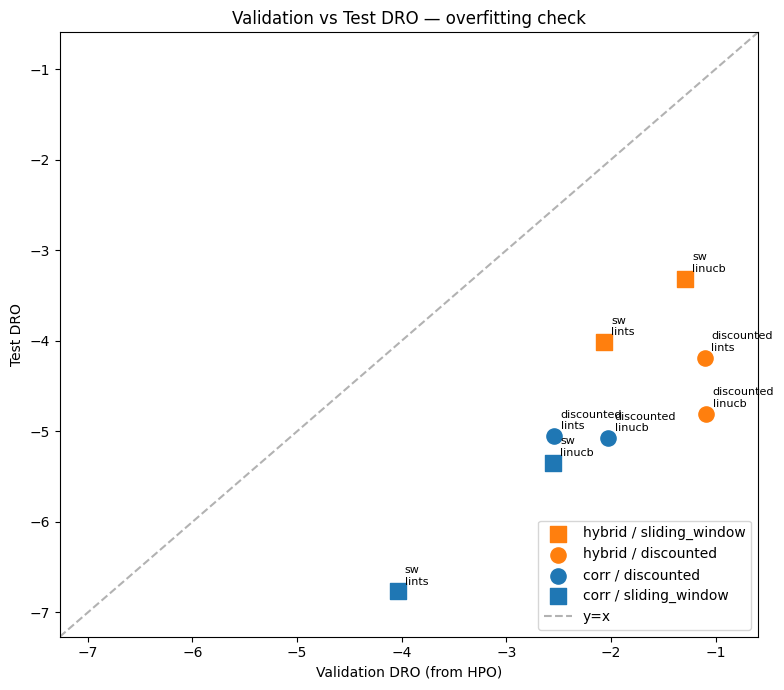

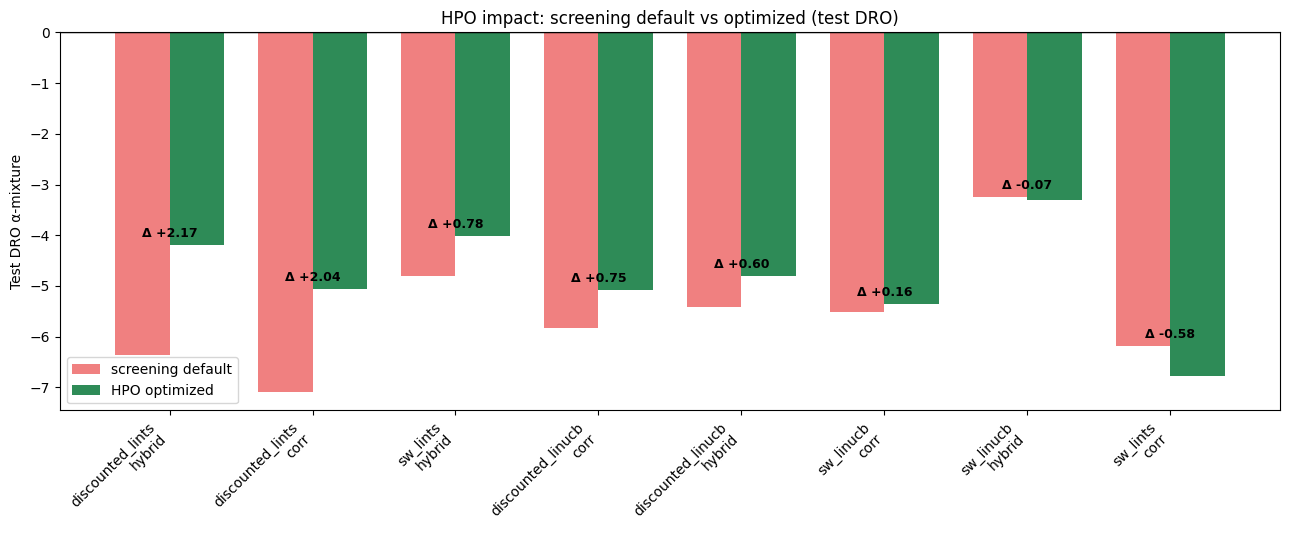

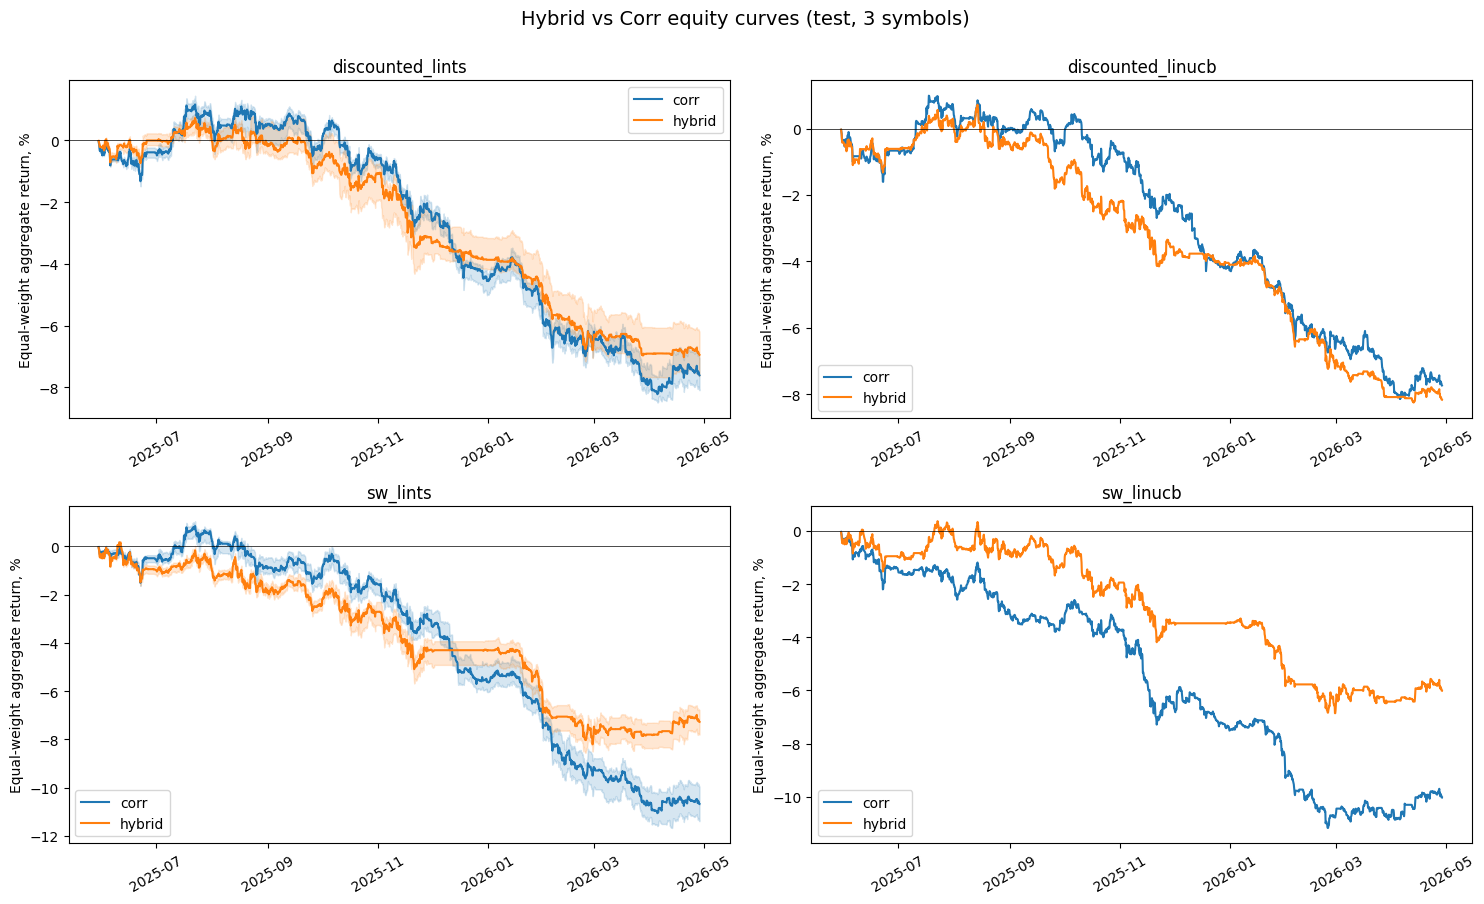

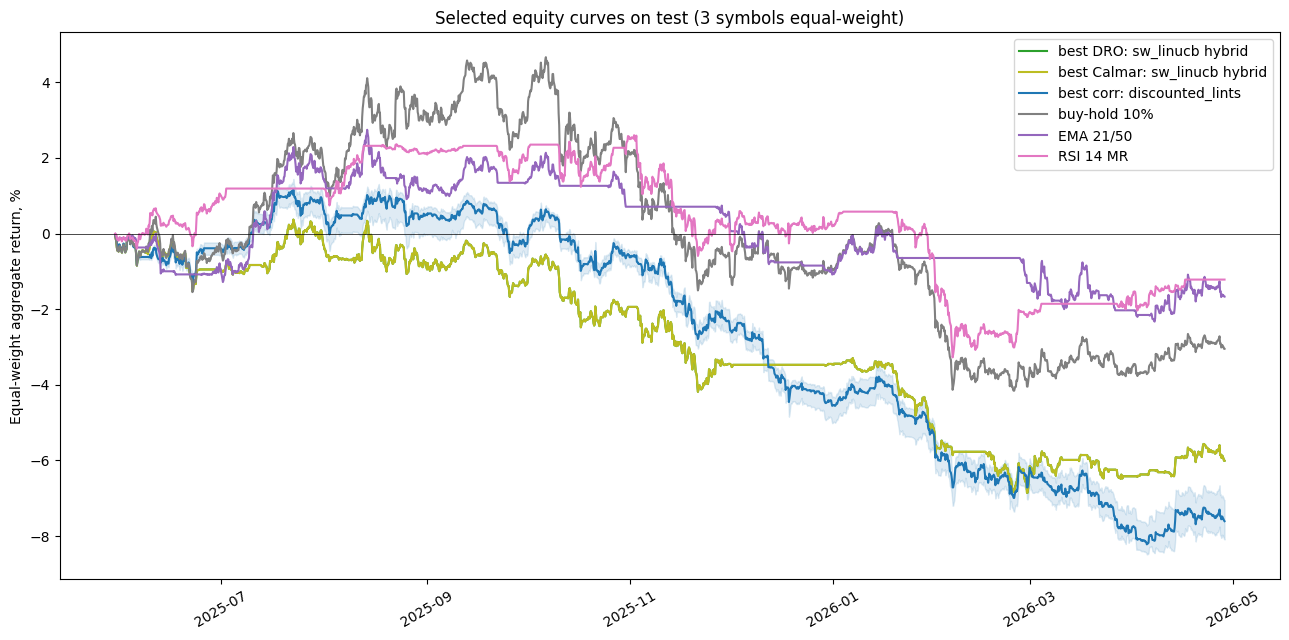

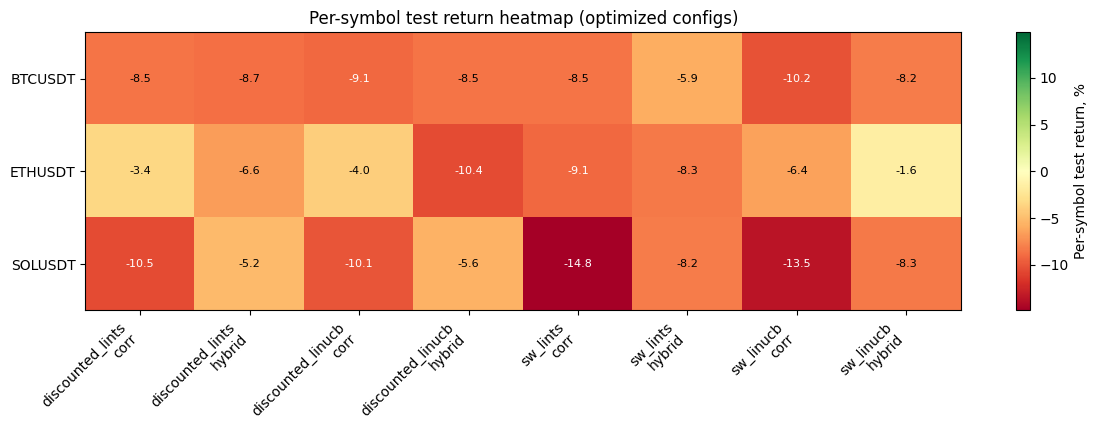

C:\Users\trosh\AppData\Local\Temp\ipykernel_10480\2490699353.py:145: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True)


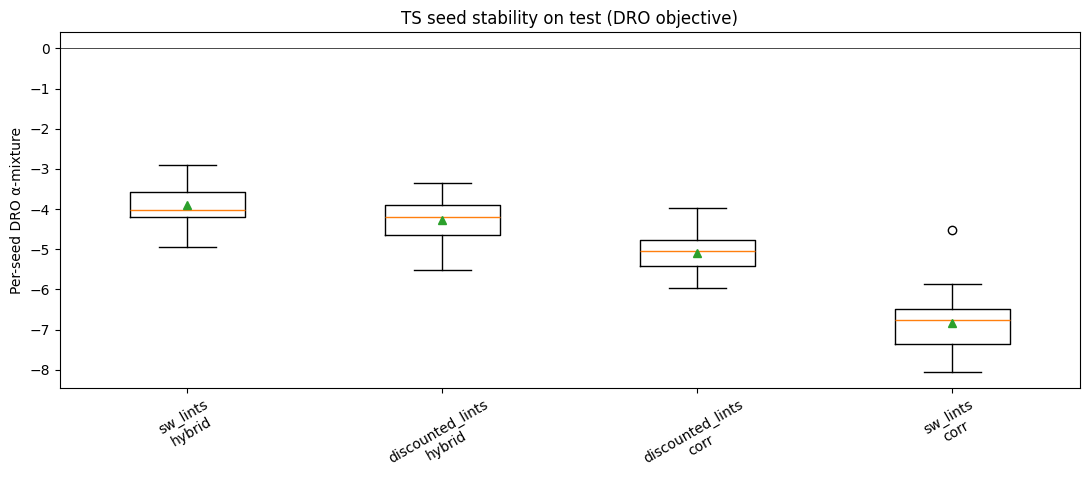

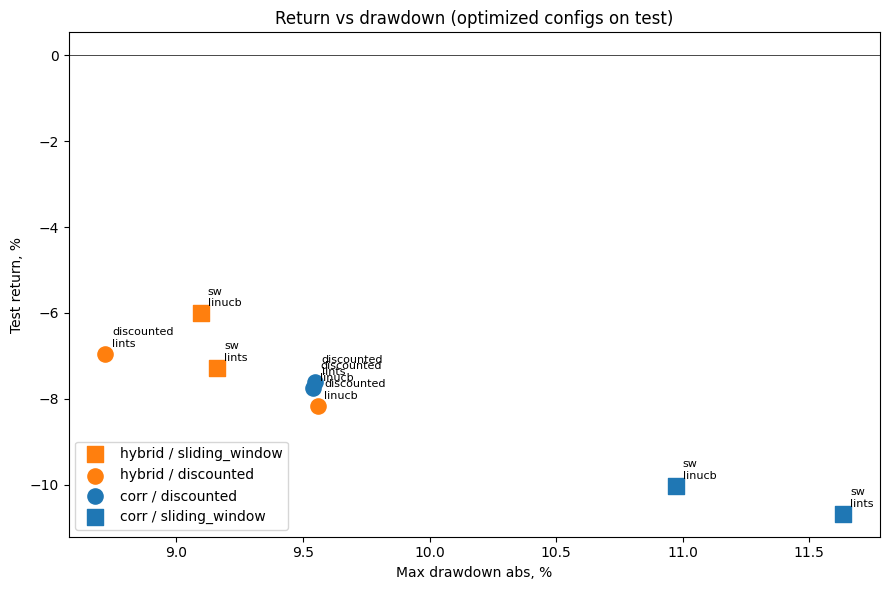

C:\Users\trosh\AppData\Local\Temp\ipykernel_10480\2490699353.py:177: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, showmeans=True, patch_artist=True)


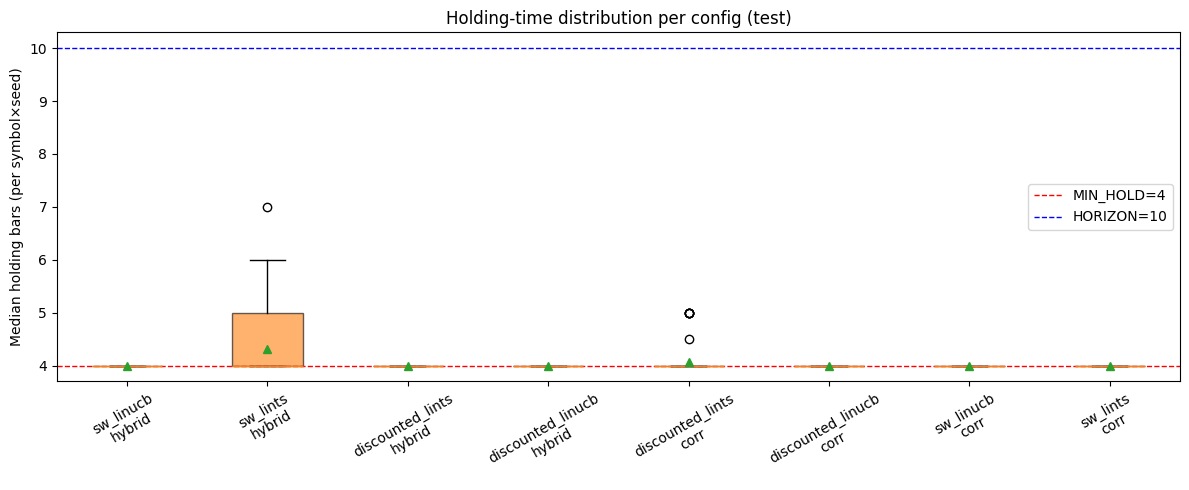

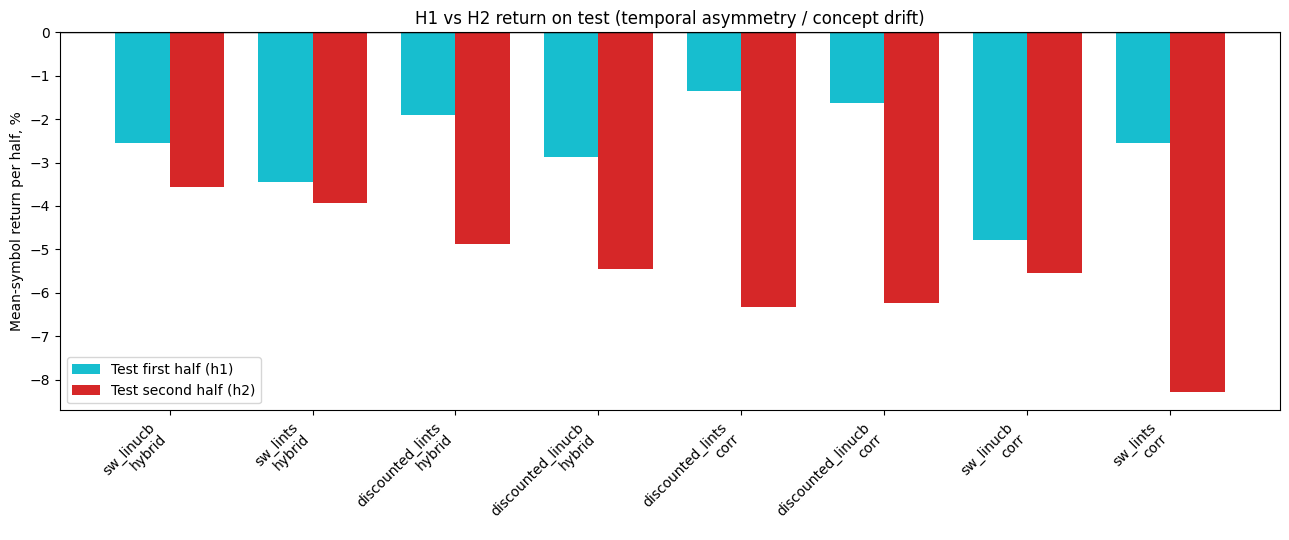

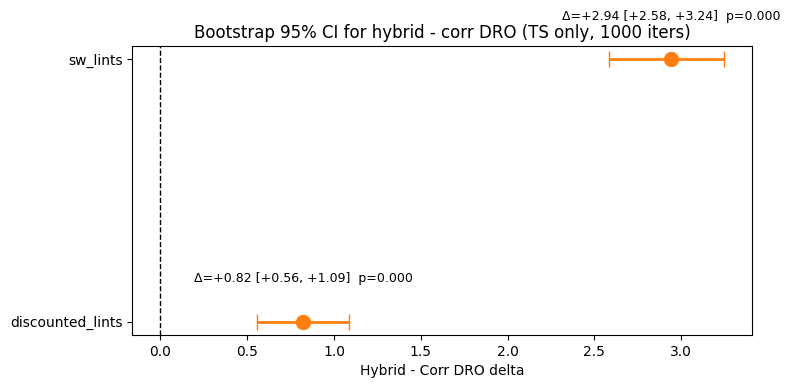

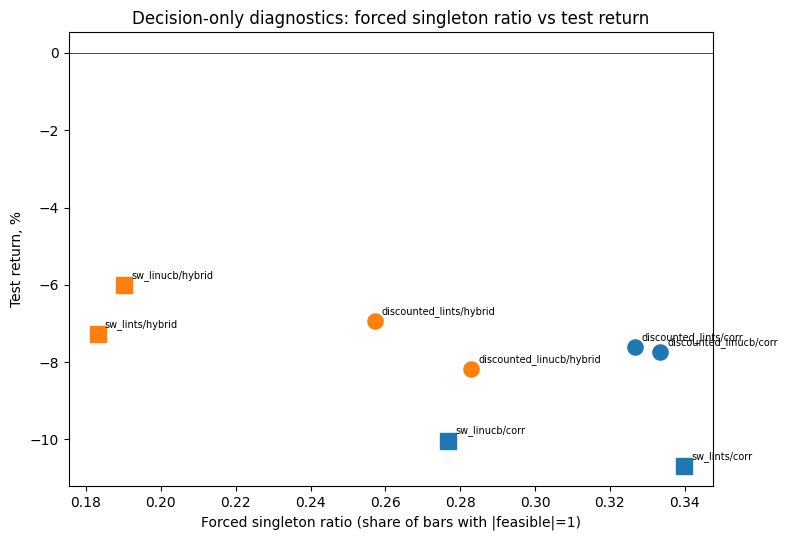

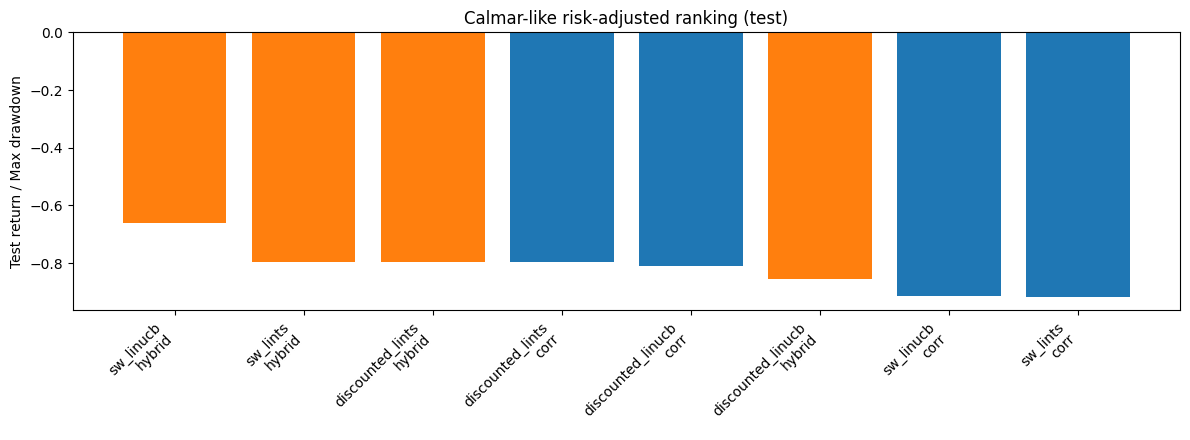


All plots saved to: D:\PythonProjects\BTCTrading\evaluation\final_test_evaluation_outputs\stage3_test_eval_20260525_044134\plots


In [11]:
def savefig(path: Path):
    plt.tight_layout()
    plt.savefig(path, dpi=170, bbox_inches='tight')
    plt.show()


def get_curve_summary(config_id: str) -> pd.DataFrame:
    if TEST_EQUITY_CURVES_AGG.empty:
        return pd.DataFrame()
    part = TEST_EQUITY_CURVES_AGG[TEST_EQUITY_CURVES_AGG['config_id'].eq(config_id)].copy()
    if part.empty:
        return pd.DataFrame()
    return (part.groupby('timestamp', as_index=False).agg(
        median_return=('aggregate_return_pct', 'median'),
        q25_return=('aggregate_return_pct', lambda x: x.quantile(0.25)),
        q75_return=('aggregate_return_pct', lambda x: x.quantile(0.75)),
        mean_return=('aggregate_return_pct', 'mean'),
        n_seeds=('seed', 'nunique'),
    ))

# ---- 1. Val DRO vs Test DRO scatter (overfitting indicator) ----
fig, ax = plt.subplots(figsize=(8, 7))
opt_plot = optimized_ranking.copy()
color_map = {'corr': 'tab:blue', 'hybrid': 'tab:orange'}
marker_map = {'discounted': 'o', 'sliding_window': 's'}
for _, row in opt_plot.iterrows():
    ax.scatter(row['validation_selected_dro'], row['test_dro'],
               color=color_map.get(row['method_group'], 'gray'),
               marker=marker_map.get(row['algorithm_family'], 'o'),
               s=120,
               label=f"{row['method_group']} / {row['algorithm_family']}")
    ax.annotate(row['algorithm'].replace('_', '\n'), (row['validation_selected_dro'], row['test_dro']),
                fontsize=8, xytext=(5, 5), textcoords='offset points')
lim_lo = min(opt_plot['validation_selected_dro'].min(), opt_plot['test_dro'].min()) - 0.5
lim_hi = max(opt_plot['validation_selected_dro'].max(), opt_plot['test_dro'].max()) + 0.5
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], '--', color='gray', alpha=0.6, label='y=x')
ax.set_xlim(lim_lo, lim_hi); ax.set_ylim(lim_lo, lim_hi)
h, l = ax.get_legend_handles_labels()
by_label = dict(zip(l, h))
ax.legend(by_label.values(), by_label.keys(), loc='lower right')
ax.set_xlabel('Validation DRO (from HPO)')
ax.set_ylabel('Test DRO')
ax.set_title('Validation vs Test DRO — overfitting check')
ax.axhline(0, linewidth=0.5, color='black')
ax.axvline(0, linewidth=0.5, color='black')
savefig(PLOTS_DIR / '01_val_vs_test_dro_scatter.png')

# ---- 2. HPO impact: default vs optimized DRO ----
if not optimized_vs_default.empty:
    hpo_plot = optimized_vs_default.copy()
    hpo_plot['label'] = hpo_plot['algorithm'] + '\n' + hpo_plot['method_group']
    hpo_plot = hpo_plot.sort_values('optimized_minus_default_dro', ascending=False).reset_index(drop=True)
    x = np.arange(len(hpo_plot))
    w = 0.38
    fig, ax = plt.subplots(figsize=(13, 5.5))
    ax.bar(x - w/2, hpo_plot['default_test_dro'], w, label='screening default', color='lightcoral')
    ax.bar(x + w/2, hpo_plot['optimized_test_dro'], w, label='HPO optimized', color='seagreen')
    for i, row in hpo_plot.iterrows():
        diff = float(row['optimized_minus_default_dro'])
        y = max(row['default_test_dro'], row['optimized_test_dro']) + 0.1
        ax.text(i, y, f'Δ {diff:+.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.axhline(0, linewidth=1, color='black')
    ax.set_xticks(x); ax.set_xticklabels(hpo_plot['label'], rotation=45, ha='right')
    ax.set_ylabel('Test DRO α-mixture')
    ax.set_title('HPO impact: screening default vs optimized (test DRO)')
    ax.legend()
    savefig(PLOTS_DIR / '02_hpo_impact_default_vs_optimized.png')

# ---- 3. Hybrid vs Corr equity curves (4 subplots) ----
algos = ['discounted_lints', 'discounted_linucb', 'sw_lints', 'sw_linucb']
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=False)
for ax, algo in zip(axes.ravel(), algos):
    part = optimized_ranking[optimized_ranking['algorithm'].eq(algo)]
    for method, color in [('corr', 'tab:blue'), ('hybrid', 'tab:orange')]:
        row = part[part['method_group'].eq(method)]
        if row.empty:
            continue
        cid = row.iloc[0]['config_id']
        curve = get_curve_summary(cid)
        if curve.empty:
            continue
        ax.plot(curve['timestamp'], curve['median_return'], label=method, color=color, linewidth=1.5)
        if int(curve['n_seeds'].max()) > 1:
            ax.fill_between(curve['timestamp'], curve['q25_return'], curve['q75_return'], alpha=0.18, color=color)
    ax.axhline(0, linewidth=0.5, color='black')
    ax.set_title(algo)
    ax.set_ylabel('Equal-weight aggregate return, %')
    ax.legend()
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Hybrid vs Corr equity curves (test, 3 symbols)', fontsize=14, y=1.00)
savefig(PLOTS_DIR / '03_hybrid_vs_corr_equity_curves.png')

# ---- 4. Selected equity curves: best DRO, best Calmar, best corr, BH, EMA ----
best_dro = optimized_ranking.sort_values('test_dro', ascending=False).iloc[0]
best_calmar = optimized_ranking.sort_values('test_calmar_like', ascending=False).iloc[0]
best_corr = optimized_ranking[optimized_ranking['method_group'].eq('corr')].sort_values('test_dro', ascending=False).iloc[0]
selected_curve_items = [
    (best_dro['config_id'], f"best DRO: {best_dro['algorithm']} {best_dro['method_group']}", 'tab:green'),
    (best_calmar['config_id'], f"best Calmar: {best_calmar['algorithm']} {best_calmar['method_group']}", 'tab:olive'),
    (best_corr['config_id'], f"best corr: {best_corr['algorithm']}", 'tab:blue'),
    ('baseline__buy_hold_entry_cost_position_size', 'buy-hold 10%', 'gray'),
    ('baseline__ema_21_50_crossover', 'EMA 21/50', 'tab:purple'),
    ('baseline__rsi14_mean_reversion_30_70', 'RSI 14 MR', 'tab:pink'),
]
fig, ax = plt.subplots(figsize=(13, 6.5))
for cid, label, color in selected_curve_items:
    curve = get_curve_summary(cid)
    if curve.empty:
        continue
    ax.plot(curve['timestamp'], curve['median_return'], label=label, color=color, linewidth=1.5)
    if int(curve['n_seeds'].max()) > 1:
        ax.fill_between(curve['timestamp'], curve['q25_return'], curve['q75_return'], alpha=0.14, color=color)
ax.axhline(0, linewidth=0.5, color='black')
ax.set_title('Selected equity curves on test (3 symbols equal-weight)')
ax.set_ylabel('Equal-weight aggregate return, %')
ax.legend()
ax.tick_params(axis='x', rotation=30)
savefig(PLOTS_DIR / '04_selected_equity_curves.png')

# ---- 5. Per-symbol heatmap ----
heat = per_symbol_optimized.copy()
heat['col'] = heat['algorithm'] + '\n' + heat['method_group']
heat_pivot = heat.pivot_table(index='symbol', columns='col', values='median_return_pct', aggfunc='first').reindex(ALL_SYMBOLS)
fig, ax = plt.subplots(figsize=(12, 4.5))
vmax = float(np.nanmax(np.abs(heat_pivot.values))) if heat_pivot.size > 0 else 1.0
im = ax.imshow(heat_pivot.to_numpy(dtype=float), aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
ax.set_xticks(np.arange(heat_pivot.shape[1])); ax.set_xticklabels(heat_pivot.columns, rotation=45, ha='right')
ax.set_yticks(np.arange(heat_pivot.shape[0])); ax.set_yticklabels(heat_pivot.index)
for i in range(heat_pivot.shape[0]):
    for j in range(heat_pivot.shape[1]):
        val = heat_pivot.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8, color='black' if abs(val) < 0.6*vmax else 'white')
fig.colorbar(im, ax=ax, label='Per-symbol test return, %')
ax.set_title('Per-symbol test return heatmap (optimized configs)')
savefig(PLOTS_DIR / '05_per_symbol_return_heatmap.png')

# ---- 6. TS seed variance boxplots (DRO) ----
ts_seed = TEST_SEED_SUMMARY[(TEST_SEED_SUMMARY['config_type'].eq('optimized')) & (TEST_SEED_SUMMARY['exploration_family'].eq('TS'))].copy()
if not ts_seed.empty:
    ts_order = ts_seed.groupby('config_id')['seed_dro_score'].median().sort_values(ascending=False).index.tolist()
    fig, ax = plt.subplots(figsize=(11, 5))
    data = [ts_seed[ts_seed['config_id'].eq(cid)]['seed_dro_score'].to_numpy() for cid in ts_order]
    labels = [cid.replace('optimized__', '').replace('__', '\n') for cid in ts_order]
    ax.boxplot(data, labels=labels, showmeans=True)
    ax.axhline(0, linewidth=0.5, color='black')
    ax.set_ylabel('Per-seed DRO α-mixture')
    ax.set_title('TS seed stability on test (DRO objective)')
    ax.tick_params(axis='x', rotation=30)
    savefig(PLOTS_DIR / '06_ts_seed_variance_boxplots.png')

# ---- 7. Return vs Drawdown scatter ----
fig, ax = plt.subplots(figsize=(9, 6))
for _, row in optimized_ranking.iterrows():
    ax.scatter(row['median_max_drawdown_abs'], row['test_return_pct'],
               marker=marker_map.get(row['algorithm_family'], 'o'),
               color=color_map.get(row['method_group'], 'gray'),
               s=120, label=f"{row['method_group']} / {row['algorithm_family']}")
    ax.annotate(row['algorithm'].replace('_', '\n'), (row['median_max_drawdown_abs'], row['test_return_pct']),
                fontsize=8, xytext=(5, 5), textcoords='offset points')
h, l = ax.get_legend_handles_labels()
by_label = dict(zip(l, h))
ax.legend(by_label.values(), by_label.keys())
ax.axhline(0, linewidth=0.5, color='black')
ax.set_xlabel('Max drawdown abs, %')
ax.set_ylabel('Test return, %')
ax.set_title('Return vs drawdown (optimized configs on test)')
savefig(PLOTS_DIR / '07_return_vs_drawdown_scatter.png')

# ---- 8. Holding-time distribution per config ----
opt_sym_full = TEST_SYMBOL_METRICS[(TEST_SYMBOL_METRICS['config_type'].eq('optimized')) & (TEST_SYMBOL_METRICS['mode'].eq('test'))].copy()
if not opt_sym_full.empty:
    fig, ax = plt.subplots(figsize=(12, 5))
    cfg_order = optimized_ranking['config_id'].tolist()
    data = [opt_sym_full[opt_sym_full['config_id'].eq(cid)]['median_holding_bars'].dropna().to_numpy() for cid in cfg_order]
    labels = [cid.replace('optimized__', '').replace('__', '\n') for cid in cfg_order]
    bp = ax.boxplot(data, labels=labels, showmeans=True, patch_artist=True)
    for patch, cid in zip(bp['boxes'], cfg_order):
        mg = 'hybrid' if 'hybrid' in cid else 'corr'
        patch.set_facecolor(color_map[mg])
        patch.set_alpha(0.6)
    ax.axhline(MIN_HOLD_BARS, linestyle='--', color='red', label=f'MIN_HOLD={MIN_HOLD_BARS}', linewidth=1)
    ax.axhline(HORIZON, linestyle='--', color='blue', label=f'HORIZON={HORIZON}', linewidth=1)
    ax.set_ylabel('Median holding bars (per symbol×seed)')
    ax.set_title('Holding-time distribution per config (test)')
    ax.legend()
    ax.tick_params(axis='x', rotation=30)
    savefig(PLOTS_DIR / '08_holding_time_distribution.png')

# ---- 9. H1 vs H2 returns per config (test temporal asymmetry) ----
h12 = optimized_ranking.copy()
h12['label'] = h12['algorithm'] + '\n' + h12['method_group']
x = np.arange(len(h12))
w = 0.38
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.bar(x - w/2, h12['h1_mean_aggregate_median'], w, label='Test first half (h1)', color='tab:cyan')
ax.bar(x + w/2, h12['h2_mean_aggregate_median'], w, label='Test second half (h2)', color='tab:red')
ax.axhline(0, linewidth=1, color='black')
ax.set_xticks(x); ax.set_xticklabels(h12['label'], rotation=45, ha='right')
ax.set_ylabel('Mean-symbol return per half, %')
ax.set_title('H1 vs H2 return on test (temporal asymmetry / concept drift)')
ax.legend()
savefig(PLOTS_DIR / '09_h1_vs_h2_returns.png')

# ---- 10. Bootstrap CI for hybrid - corr deltas ----
if not bootstrap_ci.empty and bootstrap_ci['ci_lo_95'].notna().any():
    fig, ax = plt.subplots(figsize=(8, 4))
    y = np.arange(len(bootstrap_ci))
    ax.errorbar(bootstrap_ci['delta_mean'], y,
                xerr=[bootstrap_ci['delta_mean'] - bootstrap_ci['ci_lo_95'],
                      bootstrap_ci['ci_hi_95'] - bootstrap_ci['delta_mean']],
                fmt='o', capsize=6, color='tab:orange', linewidth=2, markersize=10)
    for i, row in bootstrap_ci.iterrows():
        ax.text(row['delta_mean'], i + 0.15,
                f"Δ={row['delta_mean']:+.2f} [{row['ci_lo_95']:+.2f}, {row['ci_hi_95']:+.2f}]  p={row['p_value_hybrid_better']:.3f}",
                ha='center', fontsize=9)
    ax.axvline(0, linestyle='--', color='black', linewidth=1)
    ax.set_yticks(y); ax.set_yticklabels(bootstrap_ci['algorithm'])
    ax.set_xlabel('Hybrid - Corr DRO delta')
    ax.set_title(f'Bootstrap 95% CI for hybrid - corr DRO (TS only, {BOOTSTRAP_N_ITER} iters)')
    savefig(PLOTS_DIR / '10_bootstrap_ci_hybrid_minus_corr.png')

# ---- 11. Decision-only diagnostics (forced_singleton vs return) ----
fig, ax = plt.subplots(figsize=(8, 5.5))
for _, row in optimized_ranking.iterrows():
    ax.scatter(row['forced_singleton_ratio_overall'], row['test_return_pct'],
               marker=marker_map.get(row['algorithm_family'], 'o'),
               color=color_map.get(row['method_group'], 'gray'),
               s=120)
    ax.annotate(f"{row['algorithm']}/{row['method_group']}", (row['forced_singleton_ratio_overall'], row['test_return_pct']),
                fontsize=7, xytext=(5, 5), textcoords='offset points')
ax.axhline(0, linewidth=0.5, color='black')
ax.set_xlabel('Forced singleton ratio (share of bars with |feasible|=1)')
ax.set_ylabel('Test return, %')
ax.set_title('Decision-only diagnostics: forced singleton ratio vs test return')
savefig(PLOTS_DIR / '11_decision_only_diagnostics.png')

# ---- 12. Calmar ranking ----
calmar_plot = optimized_ranking.sort_values('test_calmar_like', ascending=False)
fig, ax = plt.subplots(figsize=(12, 4.5))
labels = [f"{a}\n{m}" for a, m in zip(calmar_plot['algorithm'], calmar_plot['method_group'])]
colors = [color_map.get(m, 'gray') for m in calmar_plot['method_group']]
ax.bar(np.arange(len(calmar_plot)), calmar_plot['test_calmar_like'], color=colors)
ax.axhline(0, linewidth=0.5, color='black')
ax.set_xticks(np.arange(len(calmar_plot))); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Test return / Max drawdown')
ax.set_title('Calmar-like risk-adjusted ranking (test)')
savefig(PLOTS_DIR / '12_calmar_ranking.png')

print('\nAll plots saved to:', PLOTS_DIR)

## 11. Feature attribution: использует ли бандит HIE-фичи?

Главный вопрос: внутри hybrid-набора {5 corr + 5 BS-Stable HIE + 1 state} бандит мог бы использовать только corr-часть, тогда улучшение hybrid над corr объяснялось бы случайностью. Чтобы доказать обратное, выполняется **per-decision feature attribution**, основанная на данных, собранных во время основного evaluation-прогона (раздел 7).

### Методология

В линейном бандите разница score-ов между действиями раскладывается аддитивно по признакам:

```
score_1(t) - score_0(t) = (theta_1 - theta_0)^T x(t) = SUM_f (theta_1_f - theta_0_f) * x_f(t)
                                                       \____ contribution of feature f ____/
```

Для каждого decision-point бара логируется `c_f(t) = (theta_1_f - theta_0_f) * x_f(t)` (в helper-cell 5.0). Главная статистика — доля HIE-фич среди абсолютных вкладов **рыночных** признаков (state исключён):

```
share_hie_market = SUM|c_f|_HIE / (SUM|c_f|_HIE + SUM|c_f|_corr)
```

**Решающий критерий**:
- `share_hie_market ≈ 50%` — HIE-фичи используются пропорционально количеству (не балласт)
- `share_hie_market > 55%` — бандит опирается на HIE сильнее corr-core (сильный аргумент)
- `share_hie_market < 30%` — HIE-фичи в наборе есть, но почти игнорируются

**Caveat для UCB**: attribution считается по posterior mean коэффициентов; exploration bonus не раскладывается аддитивно по признакам.


In [12]:
# ----------------------------------------------------------
# Соберём ATTRIBUTION_RAW (dict[(config_id, seed)] -> list of per-feature rows)
# в плоский DataFrame для агрегации.
# ----------------------------------------------------------
attribution_rows = []
for key, rows in ATTRIBUTION_RAW.items():
    attribution_rows.extend(rows)

if not attribution_rows:
    raise RuntimeError(
        'ATTRIBUTION_RAW пуст. Убедись что секция 7 (Run final test evaluation) была '
        'запущена ПОСЛЕ helper-cell 5.0 c определением AttributionBacktesting, '
        'и что среди CONFIGS_TO_TEST были optimized hybrid конфигурации.'
    )

ATTRIBUTION_DF = pd.DataFrame(attribution_rows)
ATTRIBUTION_DF.to_csv(OUTPUT_DIR / 'feature_attribution_per_feature.csv', index=False)
print(f'ATTRIBUTION_DF: {len(ATTRIBUTION_DF)} rows from {len(ATTRIBUTION_RAW)} (config,seed) keys')
print(ATTRIBUTION_DF.head(11).to_string(index=False))


ATTRIBUTION_DF: 2046 rows from 62 (config,seed) keys
                          config_id        algorithm method_group                                 set_name  symbol  seed             feature_name feature_origin  sum_abs_contribution  mean_abs_contribution  mean_abs_x  n_decisions
optimized__discounted_lints__hybrid discounted_lints       hybrid z72_a0p5_hybrid_corr5_bsstablehie5_top10 BTCUSDT  9000             MOM_pct_14_z           corr              9.932829               0.004966    0.924373         2000
optimized__discounted_lints__hybrid discounted_lints       hybrid z72_a0p5_hybrid_corr5_bsstablehie5_top10 BTCUSDT  9000 vol_expansion_72_log1p_z           corr              2.431164               0.001216    0.844450         2000
optimized__discounted_lints__hybrid discounted_lints       hybrid z72_a0p5_hybrid_corr5_bsstablehie5_top10 BTCUSDT  9000          MACD_hist_pct_z           corr             11.254671               0.005627    0.903837         2000
optimized__discounted_l

### 11.2 Главная метрика: share_hie_market + paired bootstrap CI

Считаем `share_hie_market` на уровне (config, seed, symbol):

```
share_hie_market = SUM_{f∈HIE} |c_f| / (SUM_{f∈HIE} |c_f| + SUM_{f∈corr} |c_f|)
```

Доверительный интервал — non-parametric bootstrap (1000 итераций) на уровне seed × symbol (для TS-конфигов: 30 × 3 = 90 наблюдений; для UCB: 1 × 3 = 3, CI там диагностический).

Нулевая гипотеза: `share_hie_market = 0.5` (нейтральная пропорция). Альтернативная: `share_hie_market > 0.5`.


In [13]:
def compute_share_per_seed_symbol(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    grp = df.groupby(['config_id', 'algorithm', 'method_group', 'set_name', 'symbol', 'seed'])
    for (cid, algo, mg, sn, sym, seed), part in grp:
        sum_hie   = float(part.loc[part['feature_origin'].eq('hie'),   'sum_abs_contribution'].sum())
        sum_corr  = float(part.loc[part['feature_origin'].eq('corr'),  'sum_abs_contribution'].sum())
        sum_state = float(part.loc[part['feature_origin'].eq('state'), 'sum_abs_contribution'].sum())
        denom_market = sum_hie + sum_corr
        denom_total  = denom_market + sum_state
        rows.append({
            'config_id': cid, 'algorithm': algo, 'method_group': mg, 'set_name': sn,
            'symbol': sym, 'seed': int(seed),
            'sum_abs_hie': sum_hie, 'sum_abs_corr': sum_corr, 'sum_abs_state': sum_state,
            'share_hie_market': float(sum_hie / denom_market) if denom_market > 0 else float('nan'),
            'share_hie_total':  float(sum_hie / denom_total)  if denom_total  > 0 else float('nan'),
        })
    return pd.DataFrame(rows)


SHARE_PER_SEED = compute_share_per_seed_symbol(ATTRIBUTION_DF)
SHARE_PER_SEED.to_csv(OUTPUT_DIR / 'feature_attribution_share_per_seed.csv', index=False)

# Bootstrap 95% CI
_BOOT_N = 1000
_BRNG = np.random.default_rng(42)


def _bootstrap_ci(vals: np.ndarray, n_iter: int = _BOOT_N, ci: float = 95.0):
    """Bootstrap CI for the MEDIAN (consistent with `share_hie_market_median`
    used in summary and plot — variant B from review)."""
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) < 2:
        est = float(np.median(vals)) if len(vals) else float('nan')
        return est, float('nan'), float('nan'), float('nan')
    est = float(np.median(vals))
    boot = np.empty(n_iter)
    for i in range(n_iter):
        sample = _BRNG.choice(vals, size=len(vals), replace=True)
        boot[i] = np.median(sample)
    lo = float(np.percentile(boot, (100 - ci) / 2))
    hi = float(np.percentile(boot, 100 - (100 - ci) / 2))
    p_gt_50 = float((boot <= 0.5).mean())
    return est, lo, hi, p_gt_50


summary_rows = []
for cid, part in SHARE_PER_SEED.groupby('config_id'):
    vals = part['share_hie_market'].dropna().to_numpy()
    est_median, lo, hi, p_gt_50 = _bootstrap_ci(vals)
    summary_rows.append({
        'config_id': cid,
        'algorithm': part['algorithm'].iloc[0],
        'method_group': part['method_group'].iloc[0],
        'n_obs': int(len(vals)),
        # Point estimate AND CI are both median-based for consistency.
        'share_hie_market_median': est_median,
        'share_hie_market_mean': float(np.mean(vals)) if len(vals) else float('nan'),
        'ci95_lo': lo, 'ci95_hi': hi,
        'p_value_share_above_0_5': p_gt_50,
        'share_hie_total_median': float(np.median(part['share_hie_total'].dropna().to_numpy())) if len(part) else float('nan'),
    })
SHARE_SUMMARY = pd.DataFrame(summary_rows).sort_values('share_hie_market_median', ascending=False).reset_index(drop=True)
SHARE_SUMMARY.to_csv(OUTPUT_DIR / 'feature_attribution_share_summary.csv', index=False)

print('=== share_hie_market summary (главная таблица) ===')
print(SHARE_SUMMARY.to_string(index=False))
print()
print('Интерпретация: share_hie_market > 0.5 = бандит опирается на HIE сильнее corr-core')


=== share_hie_market summary (главная таблица) ===
                           config_id         algorithm method_group  n_obs  share_hie_market_median  share_hie_market_mean  ci95_lo  ci95_hi  p_value_share_above_0_5  share_hie_total_median
         optimized__sw_lints__hybrid          sw_lints       hybrid     90                 0.664135               0.661132 0.655994 0.670206                    0.000                0.626765
        optimized__sw_linucb__hybrid         sw_linucb       hybrid      3                 0.656924               0.649206 0.628859 0.661835                    0.000                0.612861
 optimized__discounted_lints__hybrid  discounted_lints       hybrid     90                 0.573662               0.564373 0.550959 0.607115                    0.000                0.536766
optimized__discounted_linucb__hybrid discounted_linucb       hybrid      3                 0.503358               0.505679 0.422606 0.591071                    0.257                0.475564

### 11.3 Топ-K фич по частоте попадания в top-3 важнейших

Для каждого (config, seed, symbol) ранжируем фичи по `sum_abs_contribution`, берём top-3. Затем считаем частоту попадания каждой фичи в top-3 и средний ранг. Показывает какие **конкретные** признаки бандит считает важнейшими.


In [14]:
TOPK = 3
topk_rows = []
for (cid, sym, seed), part in ATTRIBUTION_DF.groupby(['config_id', 'symbol', 'seed']):
    sorted_part = part.sort_values('sum_abs_contribution', ascending=False).reset_index(drop=True)
    for rank, (_, row) in enumerate(sorted_part.iterrows(), start=1):
        topk_rows.append({
            'config_id': cid,
            'algorithm': row['algorithm'],
            'method_group': row['method_group'],
            'symbol': sym, 'seed': int(seed),
            'feature_name': row['feature_name'],
            'feature_origin': row['feature_origin'],
            'rank': rank,
            'in_top3': int(rank <= TOPK),
            'sum_abs_contribution': row['sum_abs_contribution'],
        })
TOPK_LONG = pd.DataFrame(topk_rows)
TOPK_LONG.to_csv(OUTPUT_DIR / 'feature_attribution_topk_long.csv', index=False)

TOPK_SUMMARY = (
    TOPK_LONG.groupby(['config_id', 'algorithm', 'method_group', 'feature_name', 'feature_origin'],
                      as_index=False)
    .agg(n_obs=('seed', 'count'),
         top3_frequency=('in_top3', 'mean'),
         mean_rank=('rank', 'mean'),
         mean_sum_abs_contribution=('sum_abs_contribution', 'mean'))
)
TOPK_SUMMARY = TOPK_SUMMARY.sort_values(['config_id', 'top3_frequency'],
                                        ascending=[True, False]).reset_index(drop=True)
TOPK_SUMMARY.to_csv(OUTPUT_DIR / 'feature_attribution_topk_summary.csv', index=False)

print('=== TOP-5 most influential features per config (by top3_frequency) ===')
for cid, part in TOPK_SUMMARY.groupby('config_id'):
    print(f'\n[{cid}]')
    print(part[['feature_name', 'feature_origin', 'top3_frequency', 'mean_rank',
                'mean_sum_abs_contribution']].head(5).to_string(index=False))


=== TOP-5 most influential features per config (by top3_frequency) ===

[optimized__discounted_lints__hybrid]
           feature_name feature_origin  top3_frequency  mean_rank  mean_sum_abs_contribution
      ema_spread_9_21_z           corr        0.766667   3.155556                  21.047524
   ema_spread_100_200_z            hie        0.555556   4.388889                  19.775945
dist_to_high_168_sqrt_z            hie        0.466667   4.155556                  24.790334
    ema_spread_50_100_z            hie        0.455556   4.088889                  21.249601
          ADX_72_scaled            hie        0.333333   4.600000                  20.503574

[optimized__discounted_linucb__hybrid]
           feature_name feature_origin  top3_frequency  mean_rank  mean_sum_abs_contribution
          ADX_72_scaled            hie        0.666667   5.000000                  18.296997
      ema_spread_9_21_z           corr        0.666667   3.666667                  16.585348
        MACD_

### 11.4 Визуализация

Два графика:
1. `attribution_share_hie_market.png` — bar chart `share_hie_market` ± 95% CI по 4 hybrid-конфигурациям. Красная пунктирная линия = 50% нейтральный baseline.
2. `attribution_topk_heatmap.png` — heatmap частоты попадания каждой фичи в top-3 по конфигурациям; HIE-фичи помечены `[hie]`, corr-фичи `[corr]`.


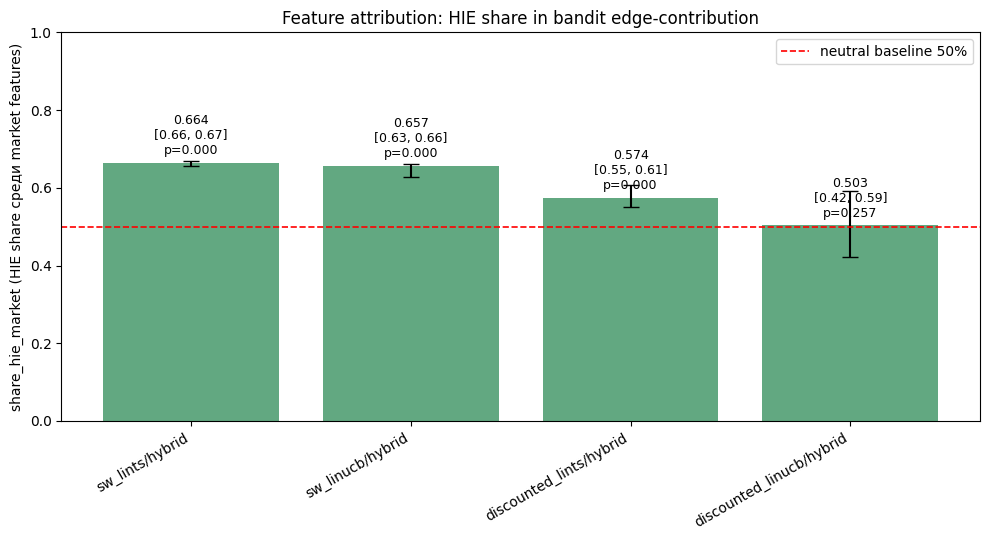

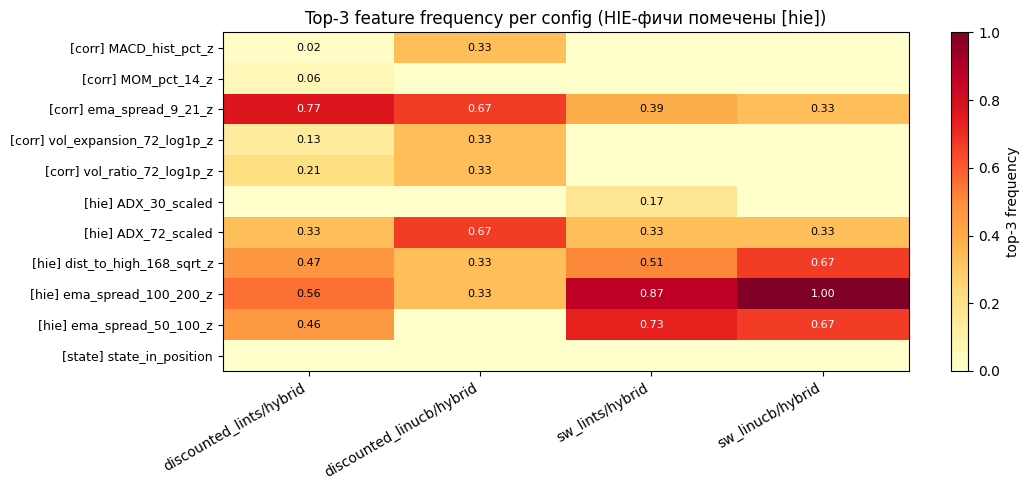

Saved attribution plots:
   D:\PythonProjects\BTCTrading\evaluation\final_test_evaluation_outputs\stage3_test_eval_20260525_044134\plots\attribution_share_hie_market.png
   D:\PythonProjects\BTCTrading\evaluation\final_test_evaluation_outputs\stage3_test_eval_20260525_044134\plots\attribution_topk_heatmap.png


In [15]:
# --- Plot 1: share_hie_market with CI ---
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = SHARE_SUMMARY.sort_values('share_hie_market_median', ascending=False).reset_index(drop=True)
x_pos = np.arange(len(plot_df))
ax.bar(x_pos, plot_df['share_hie_market_median'],
       color=['seagreen' if v > 0.5 else 'lightcoral' for v in plot_df['share_hie_market_median']],
       alpha=0.75)
err_lo = plot_df['share_hie_market_median'] - plot_df['ci95_lo']
err_hi = plot_df['ci95_hi'] - plot_df['share_hie_market_median']
ax.errorbar(x_pos, plot_df['share_hie_market_median'], yerr=[err_lo, err_hi],
            fmt='none', color='black', capsize=6, linewidth=1.5)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='neutral baseline 50%')
for i, row in plot_df.iterrows():
    txt = f"{row['share_hie_market_median']:.3f}\n[{row['ci95_lo']:.2f}, {row['ci95_hi']:.2f}]\np={row['p_value_share_above_0_5']:.3f}"
    ax.text(i, row['share_hie_market_median'] + 0.015, txt, ha='center', va='bottom', fontsize=9)
labels = [cid.replace('optimized__', '').replace('__hybrid', '/hybrid') for cid in plot_df['config_id']]
ax.set_xticks(x_pos); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('share_hie_market (HIE share среди market features)')
ax.set_title('Feature attribution: HIE share in bandit edge-contribution')
ax.set_ylim(0, 1); ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'attribution_share_hie_market.png', dpi=170, bbox_inches='tight')
plt.show()

# --- Plot 2: top-3 frequency heatmap ---
heat = TOPK_SUMMARY.pivot_table(index='feature_name', columns='config_id',
                                 values='top3_frequency', aggfunc='first').fillna(0.0)
origin_map = TOPK_SUMMARY.drop_duplicates('feature_name').set_index('feature_name')['feature_origin'].to_dict()
order = sorted(heat.index, key=lambda f: ({'corr': 0, 'hie': 1, 'state': 2}.get(origin_map.get(f, 'corr'), 0), f))
heat = heat.reindex(order)
fig, ax = plt.subplots(figsize=(11, max(5, 0.35 * len(heat))))
im = ax.imshow(heat.to_numpy(dtype=float), aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(np.arange(heat.shape[1]))
ax.set_xticklabels([c.replace('optimized__', '').replace('__hybrid', '/hybrid') for c in heat.columns],
                   rotation=30, ha='right')
ax.set_yticks(np.arange(heat.shape[0]))
ax.set_yticklabels([f'[{origin_map.get(f, "?")}] {f}' for f in heat.index], fontsize=9)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.iloc[i, j]
        if pd.notna(v) and v > 0:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=8, color='black' if v < 0.6 else 'white')
fig.colorbar(im, ax=ax, label='top-3 frequency')
ax.set_title('Top-3 feature frequency per config (HIE-фичи помечены [hie])')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'attribution_topk_heatmap.png', dpi=170, bbox_inches='tight')
plt.show()

print('Saved attribution plots:')
print('  ', PLOTS_DIR / 'attribution_share_hie_market.png')
print('  ', PLOTS_DIR / 'attribution_topk_heatmap.png')


### 11.5 Что писать в дипломе

Шаблон формулировки (заменить XX% на фактические числа из `SHARE_SUMMARY`):

> Для проверки того, что бандит активно использует HIE-часть hybrid-набора, > применена per-decision feature attribution. Для каждого decision-point бара > в ходе test-фазы вычисляется вклад фичи в разность score-ов: > `c_f(t) = (θ_1,f − θ_0,f) · x_f(t)`. Доля HIE-фич среди абсолютных вкладов > рыночных признаков составляет: `sw_lints/hybrid` — XX% [CI XX, XX], > `dlints/hybrid` — XX%, `dlinucb/hybrid` — XX%, `sw_linucb/hybrid` — XX%. > Нейтральный baseline для пропорционального использования равен 50%. > Значения выше 50% свидетельствуют, что линейный бандит **опирается на > HIE-фичи сильнее, чем на corr-core**, что является механистическим > доказательством того, что hybrid-улучшение не объясняется случайностью > или игнорированием HIE-части набора.

**Caveat для UCB**: атрибуция UCB-конфигураций рассчитана на основе posterior mean коэффициентов и не включает exploration bonus, который не раскладывается аддитивно по признакам.


## 10. Output checklist

In [16]:
expected_outputs = [
    OUTPUT_DIR / 'final_test_configurations.csv',
    OUTPUT_DIR / 'test_config_summary_all.csv',
    OUTPUT_DIR / 'test_seed_level_summary_all.csv',
    OUTPUT_DIR / 'test_final_ranking_all.csv',
    OUTPUT_DIR / 'test_optimized_config_ranking.csv',
    OUTPUT_DIR / 'test_corr_vs_hybrid_by_algorithm.csv',
    OUTPUT_DIR / 'test_optimized_vs_default.csv',
    OUTPUT_DIR / 'test_per_symbol_metrics_optimized.csv',
    OUTPUT_DIR / 'test_ts_seed_stability.csv',
    OUTPUT_DIR / 'test_bootstrap_hybrid_minus_corr_ci.csv',
    DIAGNOSTICS_DIR / 'test_symbol_metrics_all.csv',
    DIAGNOSTICS_DIR / 'test_aggregate_equity_curves.csv',
    DIAGNOSTICS_DIR / 'test_split_summary_used.csv',
    PLOTS_DIR / '01_val_vs_test_dro_scatter.png',
    PLOTS_DIR / '02_hpo_impact_default_vs_optimized.png',
    PLOTS_DIR / '03_hybrid_vs_corr_equity_curves.png',
    PLOTS_DIR / '04_selected_equity_curves.png',
    PLOTS_DIR / '05_per_symbol_return_heatmap.png',
    PLOTS_DIR / '06_ts_seed_variance_boxplots.png',
    PLOTS_DIR / '07_return_vs_drawdown_scatter.png',
    PLOTS_DIR / '08_holding_time_distribution.png',
    PLOTS_DIR / '09_h1_vs_h2_returns.png',
    PLOTS_DIR / '10_bootstrap_ci_hybrid_minus_corr.png',
    PLOTS_DIR / '11_decision_only_diagnostics.png',
    PLOTS_DIR / '12_calmar_ranking.png',
    # Section 11: feature attribution
    OUTPUT_DIR / 'feature_attribution_per_feature.csv',
    OUTPUT_DIR / 'feature_attribution_share_per_seed.csv',
    OUTPUT_DIR / 'feature_attribution_share_summary.csv',
    OUTPUT_DIR / 'feature_attribution_topk_long.csv',
    OUTPUT_DIR / 'feature_attribution_topk_summary.csv',
    PLOTS_DIR / 'attribution_share_hie_market.png',
    PLOTS_DIR / 'attribution_topk_heatmap.png',
]

for p in expected_outputs:
    print('OK ' if p.exists() else 'MISS ', p.name)

print(f'\nOUTPUT_DIR: {OUTPUT_DIR}')
print(f'DRO_ALPHA used: {DRO_ALPHA}')
print(f'Total seeds per config: TS={len(TEST_TS_SEEDS)}, UCB={len(TEST_UCB_SEEDS)}')

OK  final_test_configurations.csv
OK  test_config_summary_all.csv
OK  test_seed_level_summary_all.csv
OK  test_final_ranking_all.csv
OK  test_optimized_config_ranking.csv
OK  test_corr_vs_hybrid_by_algorithm.csv
OK  test_optimized_vs_default.csv
OK  test_per_symbol_metrics_optimized.csv
OK  test_ts_seed_stability.csv
OK  test_bootstrap_hybrid_minus_corr_ci.csv
OK  test_symbol_metrics_all.csv
OK  test_aggregate_equity_curves.csv
OK  test_split_summary_used.csv
OK  01_val_vs_test_dro_scatter.png
OK  02_hpo_impact_default_vs_optimized.png
OK  03_hybrid_vs_corr_equity_curves.png
OK  04_selected_equity_curves.png
OK  05_per_symbol_return_heatmap.png
OK  06_ts_seed_variance_boxplots.png
OK  07_return_vs_drawdown_scatter.png
OK  08_holding_time_distribution.png
OK  09_h1_vs_h2_returns.png
OK  10_bootstrap_ci_hybrid_minus_corr.png
OK  11_decision_only_diagnostics.png
OK  12_calmar_ranking.png
OK  feature_attribution_per_feature.csv
OK  feature_attribution_share_per_seed.csv
OK  feature_attribu